# Multiple-objective portfolio optimization

 Weight's Order:
 
 - 1 SuperFuture
 - 2 Apples
 - 3 WorldNow
 - 4 Electronics123
 - 5 Photons
 - 6 SpaceNow
 - 7 PearPear
 - 8 PositiveCorrelation
 - 9 BetterTechnology
 - 10 ABCDE
 - 11 EnviroLike
 - 12 Moneymakers
 - 13 Fuel4
 - 14 MarsProject
 - 15 CPU-XYZ
 - 16 RoboticsX
 - 17 Lasers
 - 18 WaterForce
 - 19 SafeAndCare
 - 20 BetterTomorrow

## Imports

In [1]:
from utils.MOO_utilities import *

In [ ]:
### SOLVE HERE

ORDER = ["SuperFuture", "Apples", "WorldNow", "Electronics123", "Photons", "SpaceNow", "PearPear",
         "PositiveCorrelation", "BetterTechnology", "ABCDE", "EnviroLike", "Moneymakers", "Fuel4",
         "MarsProject", "CPU-XYZ", "RoboticsX", "Lasers", "WaterForce", "SafeAndCare", "BetterTomorrow"]

## Data

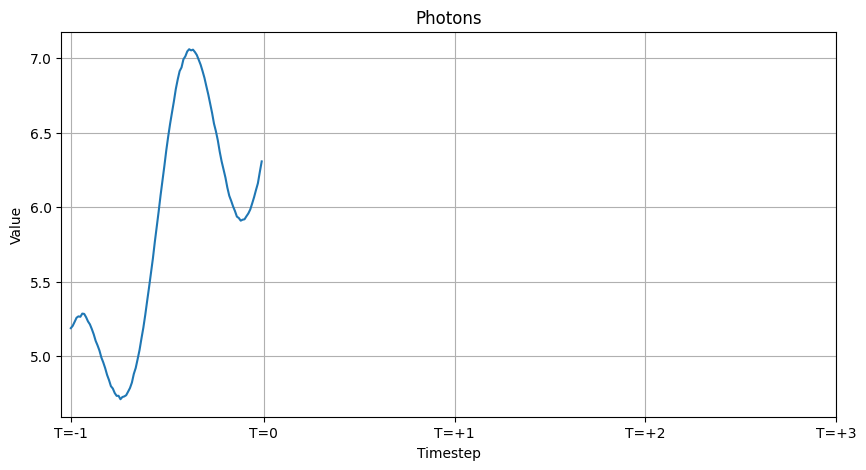

In [3]:
dr = DataReader("./data/Bundle1")
dr.read_data()
dr.plot()
data = dr.get_data()
assert len(data.keys()) == 20

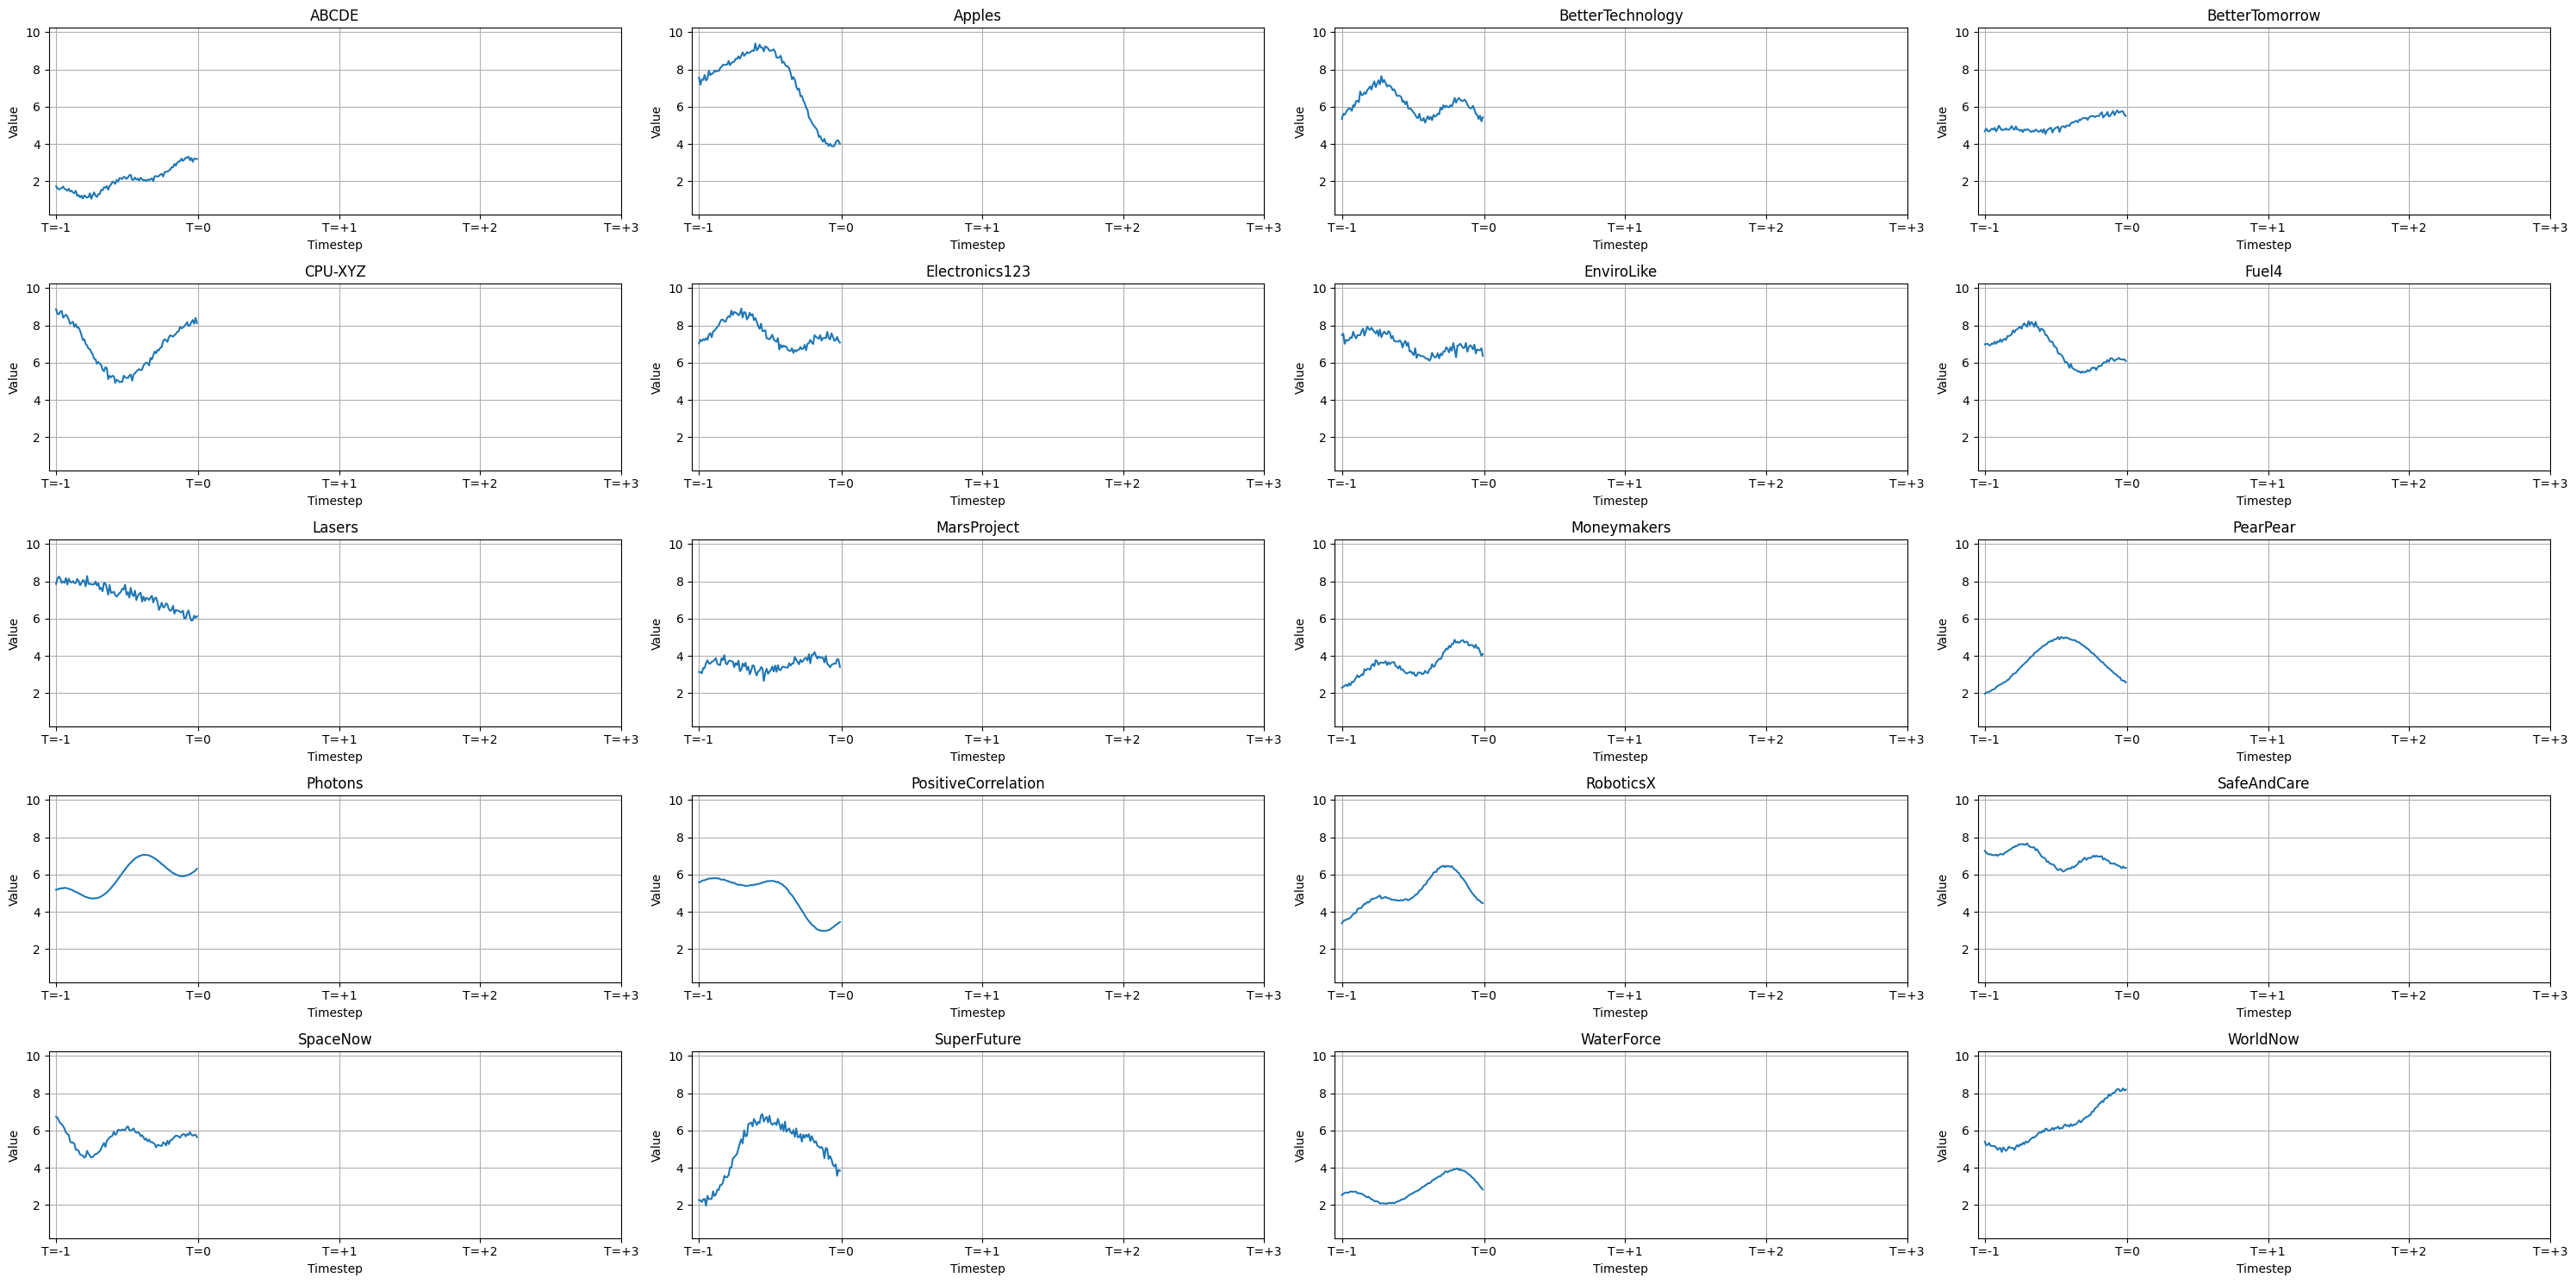

In [4]:
dr.plot_all(figsize=(30, 15), normalized_y=True)

## Regression Algorithms

### Linear Regression

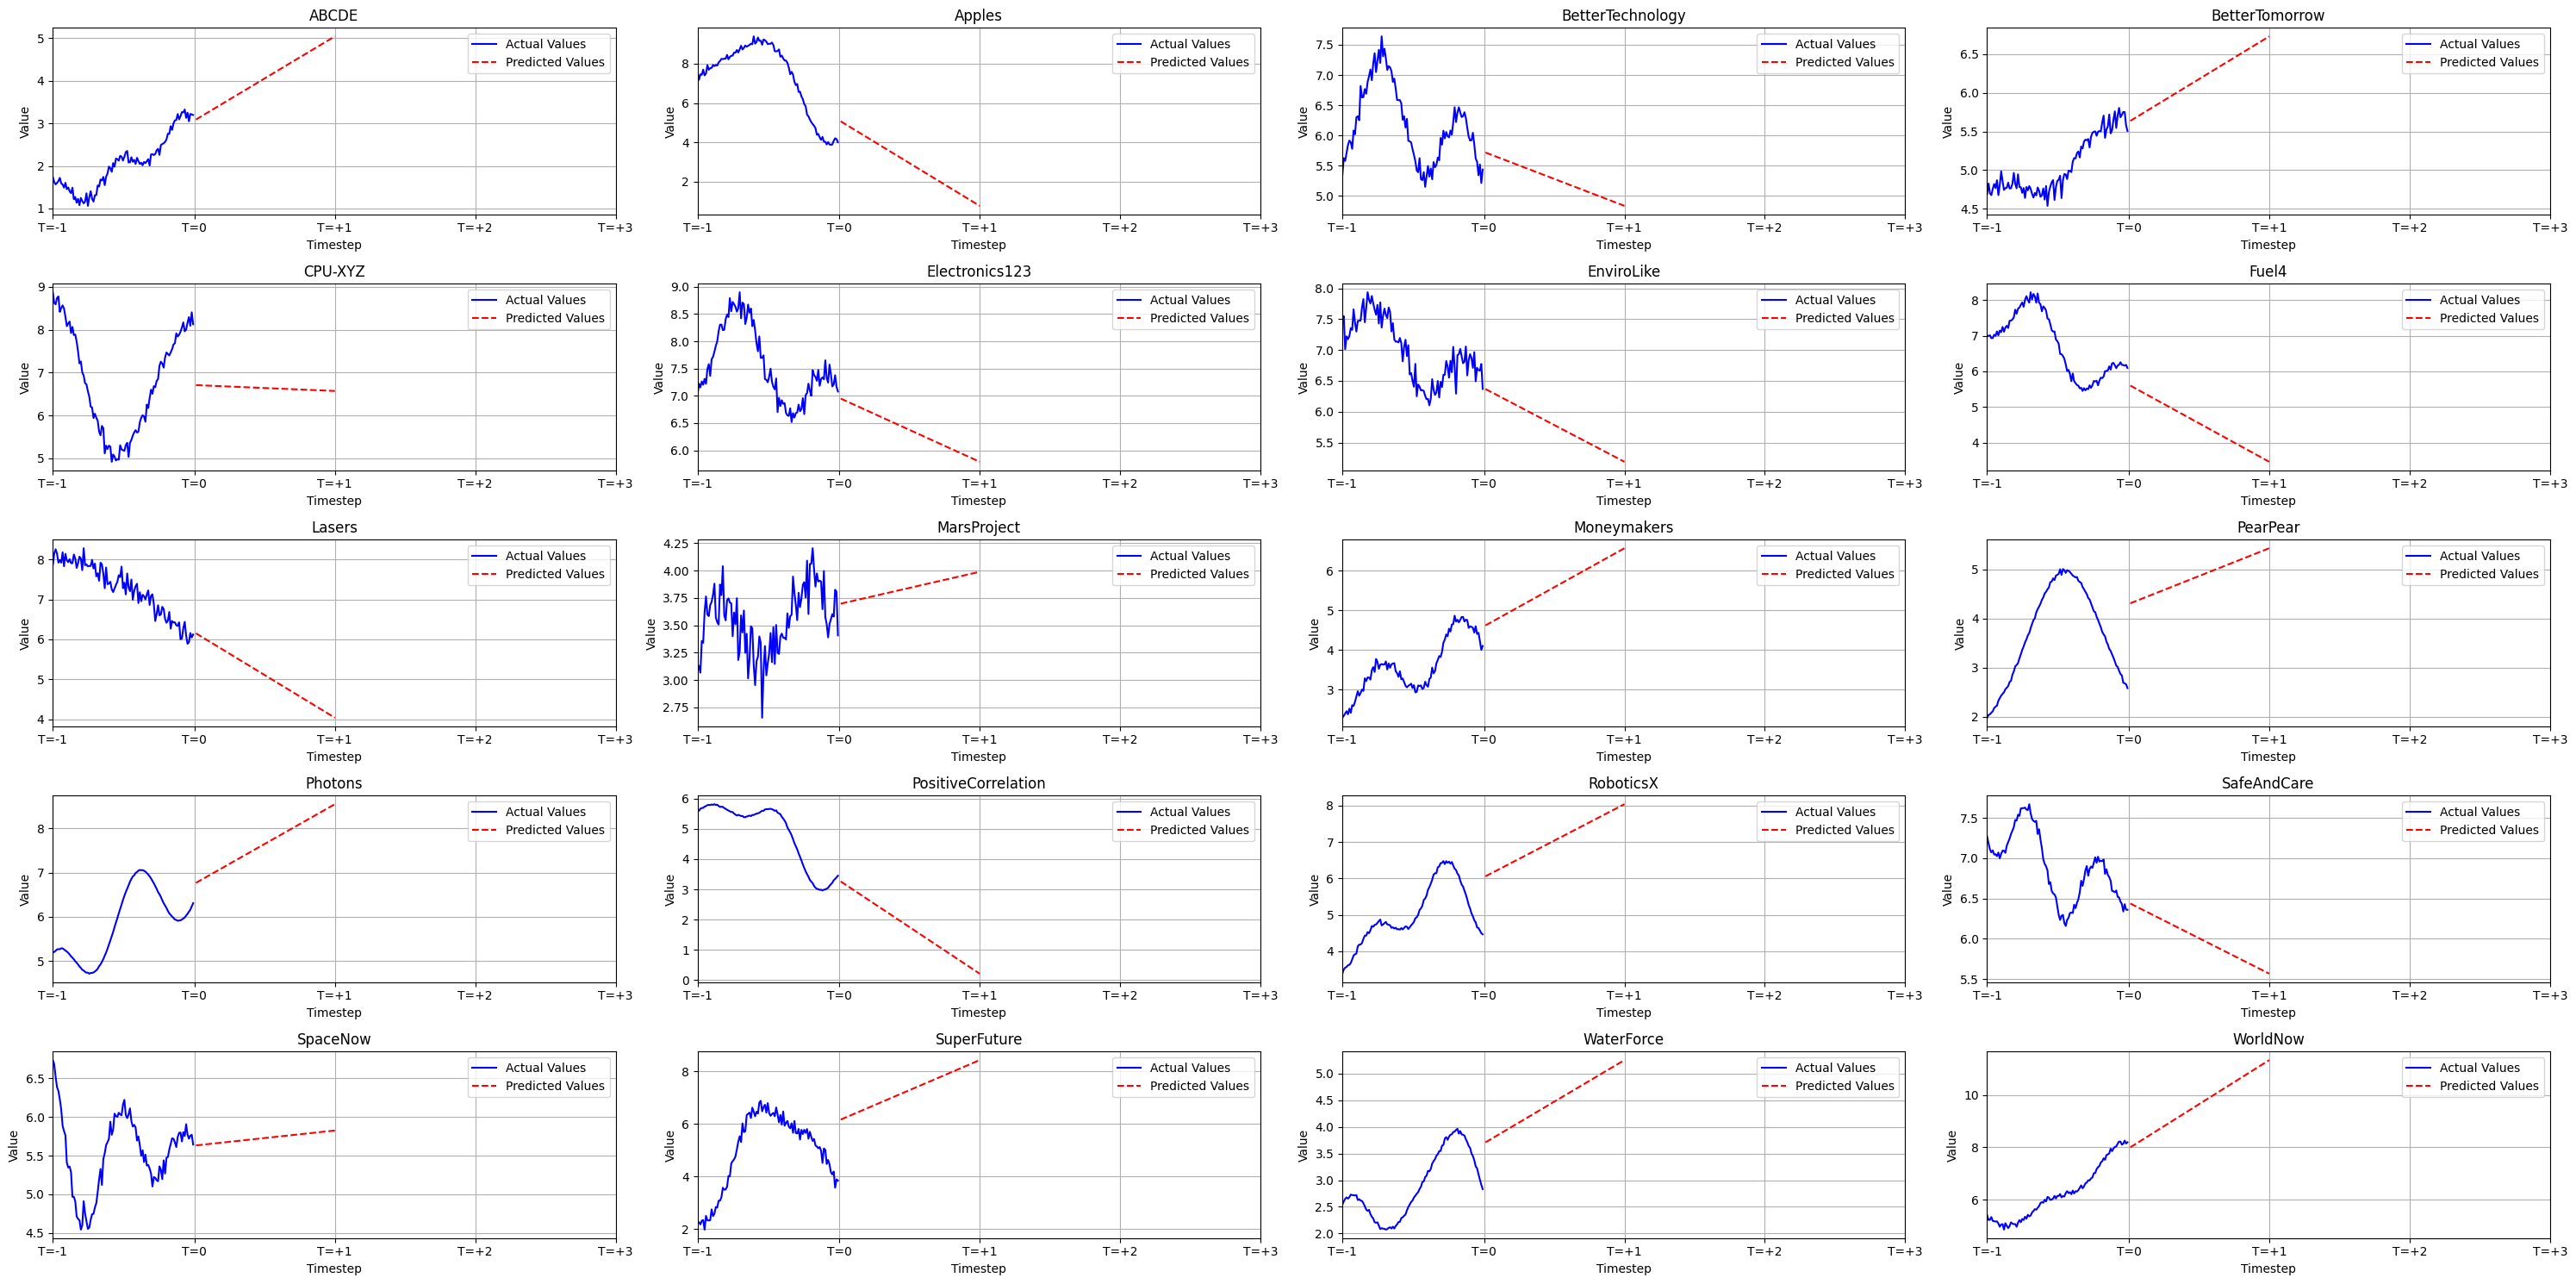

In [5]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_linear()
linear_predictions = RMC.predict_linear()
RMC.plot_predictions(val_range=201, predictions=linear_predictions, figsize=(30, 15))

### Sinusoidal Regression

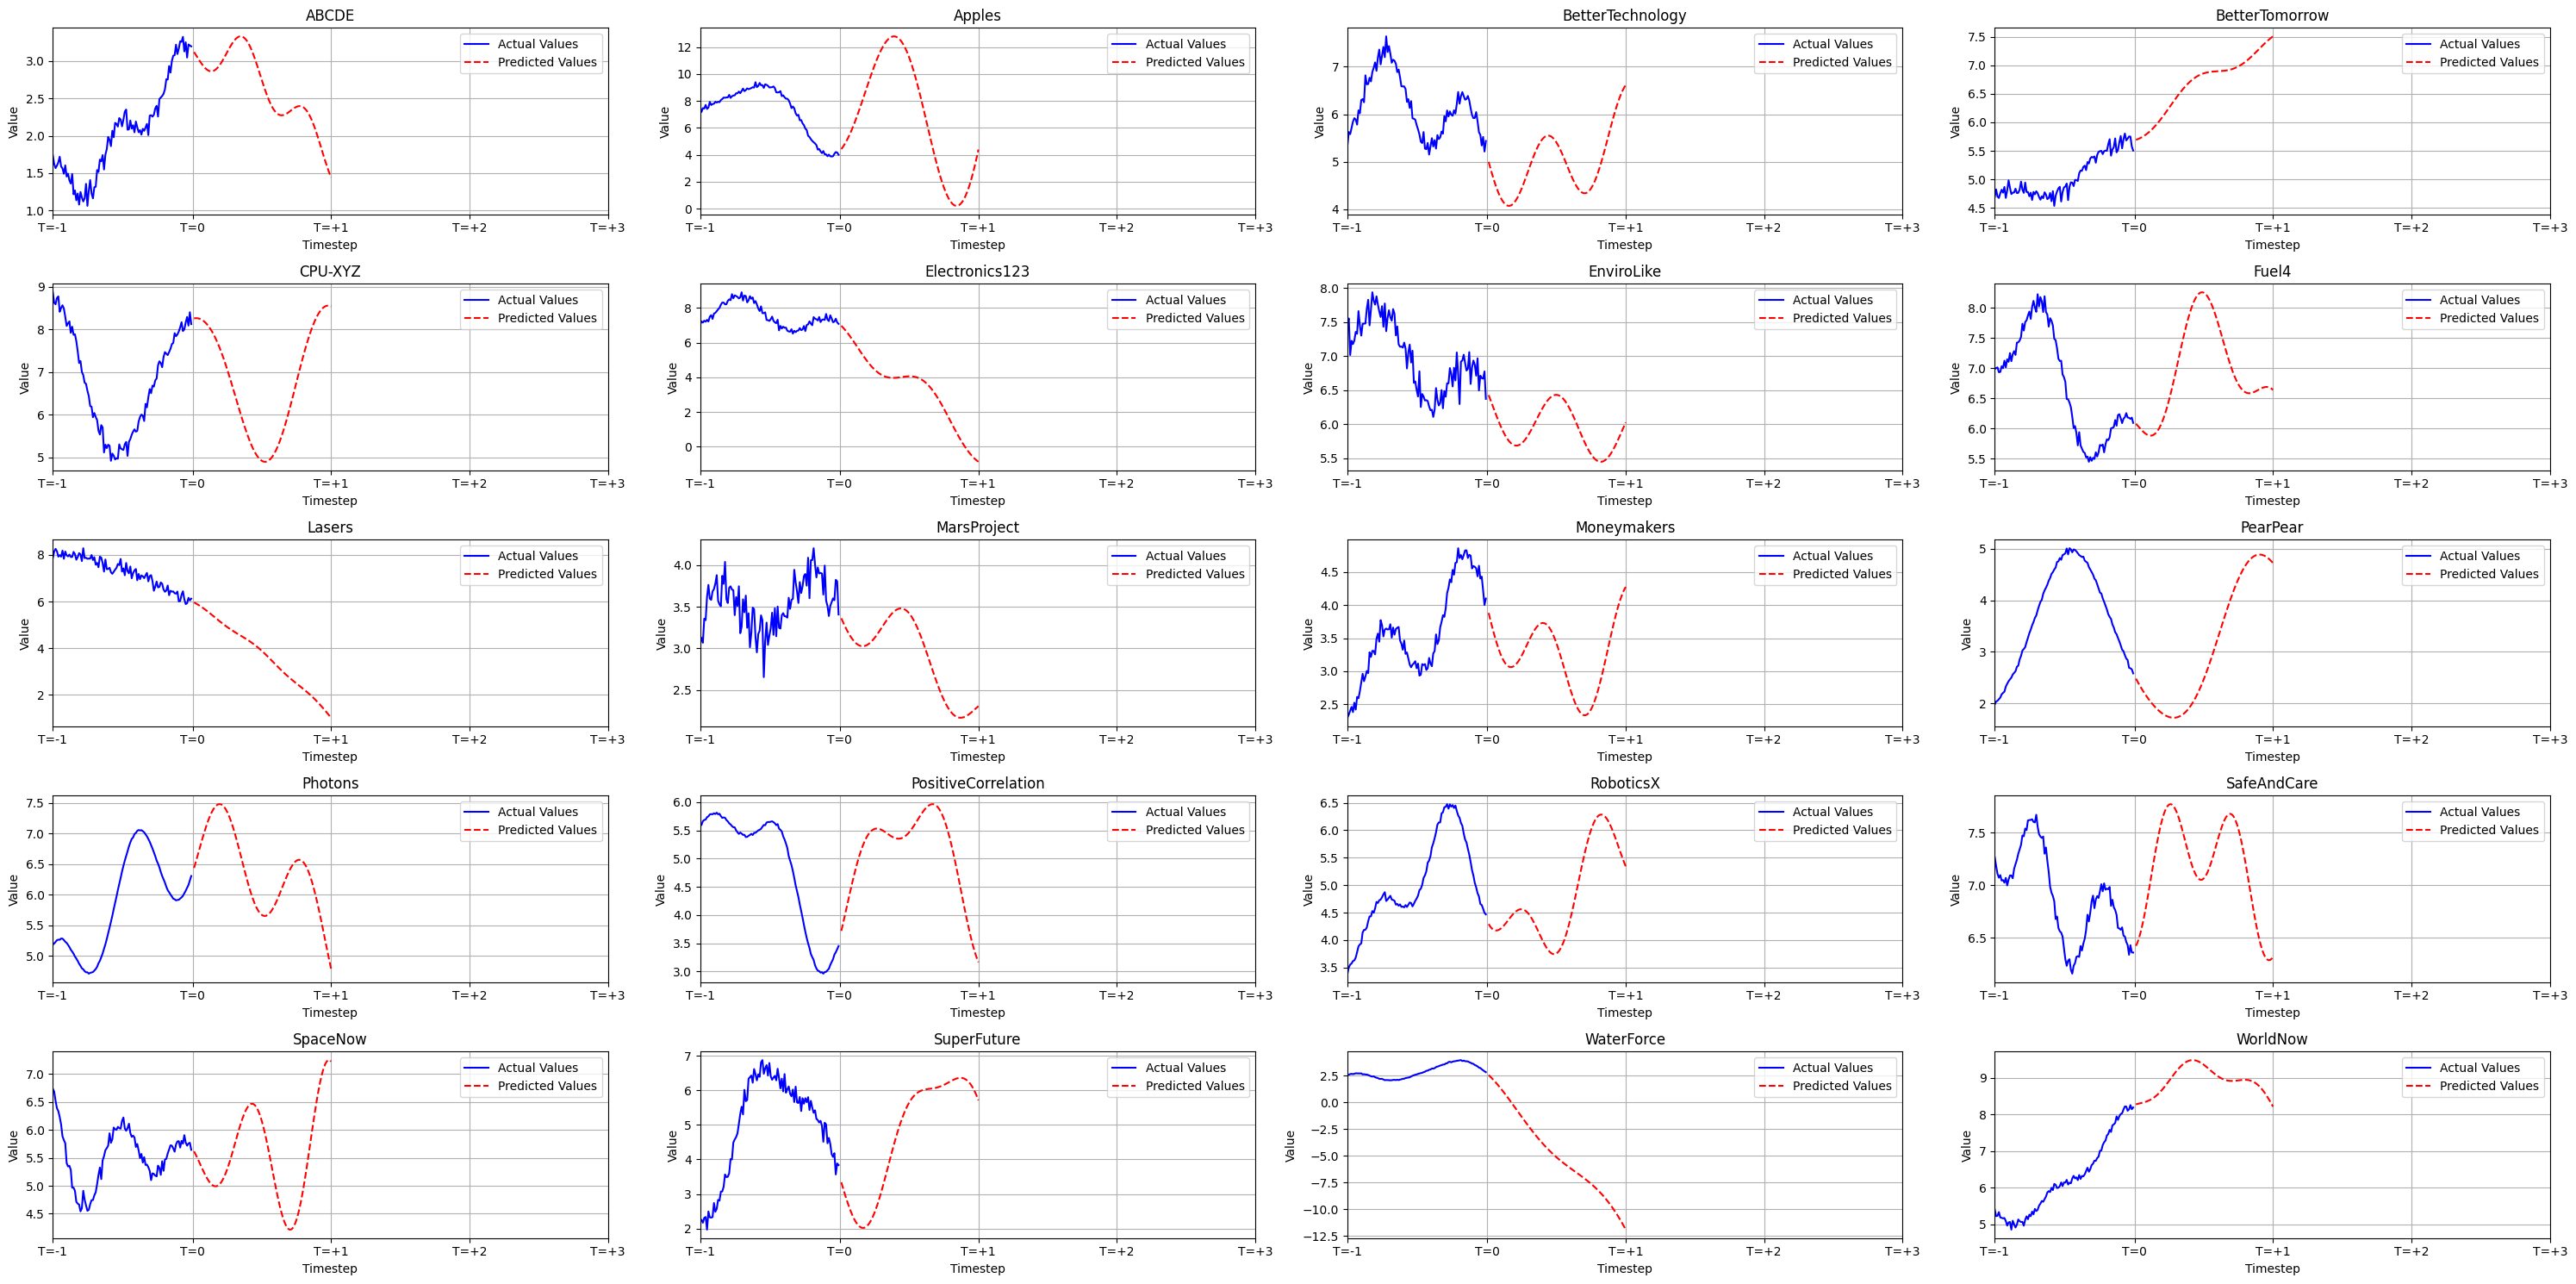

In [6]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_sinusoidal()
sinusoidal_predictions = RMC.predict_sinusoidal()
RMC.plot_predictions(val_range=201, predictions=sinusoidal_predictions, figsize=(30, 15))

### Sinusoidal + Linear Regression

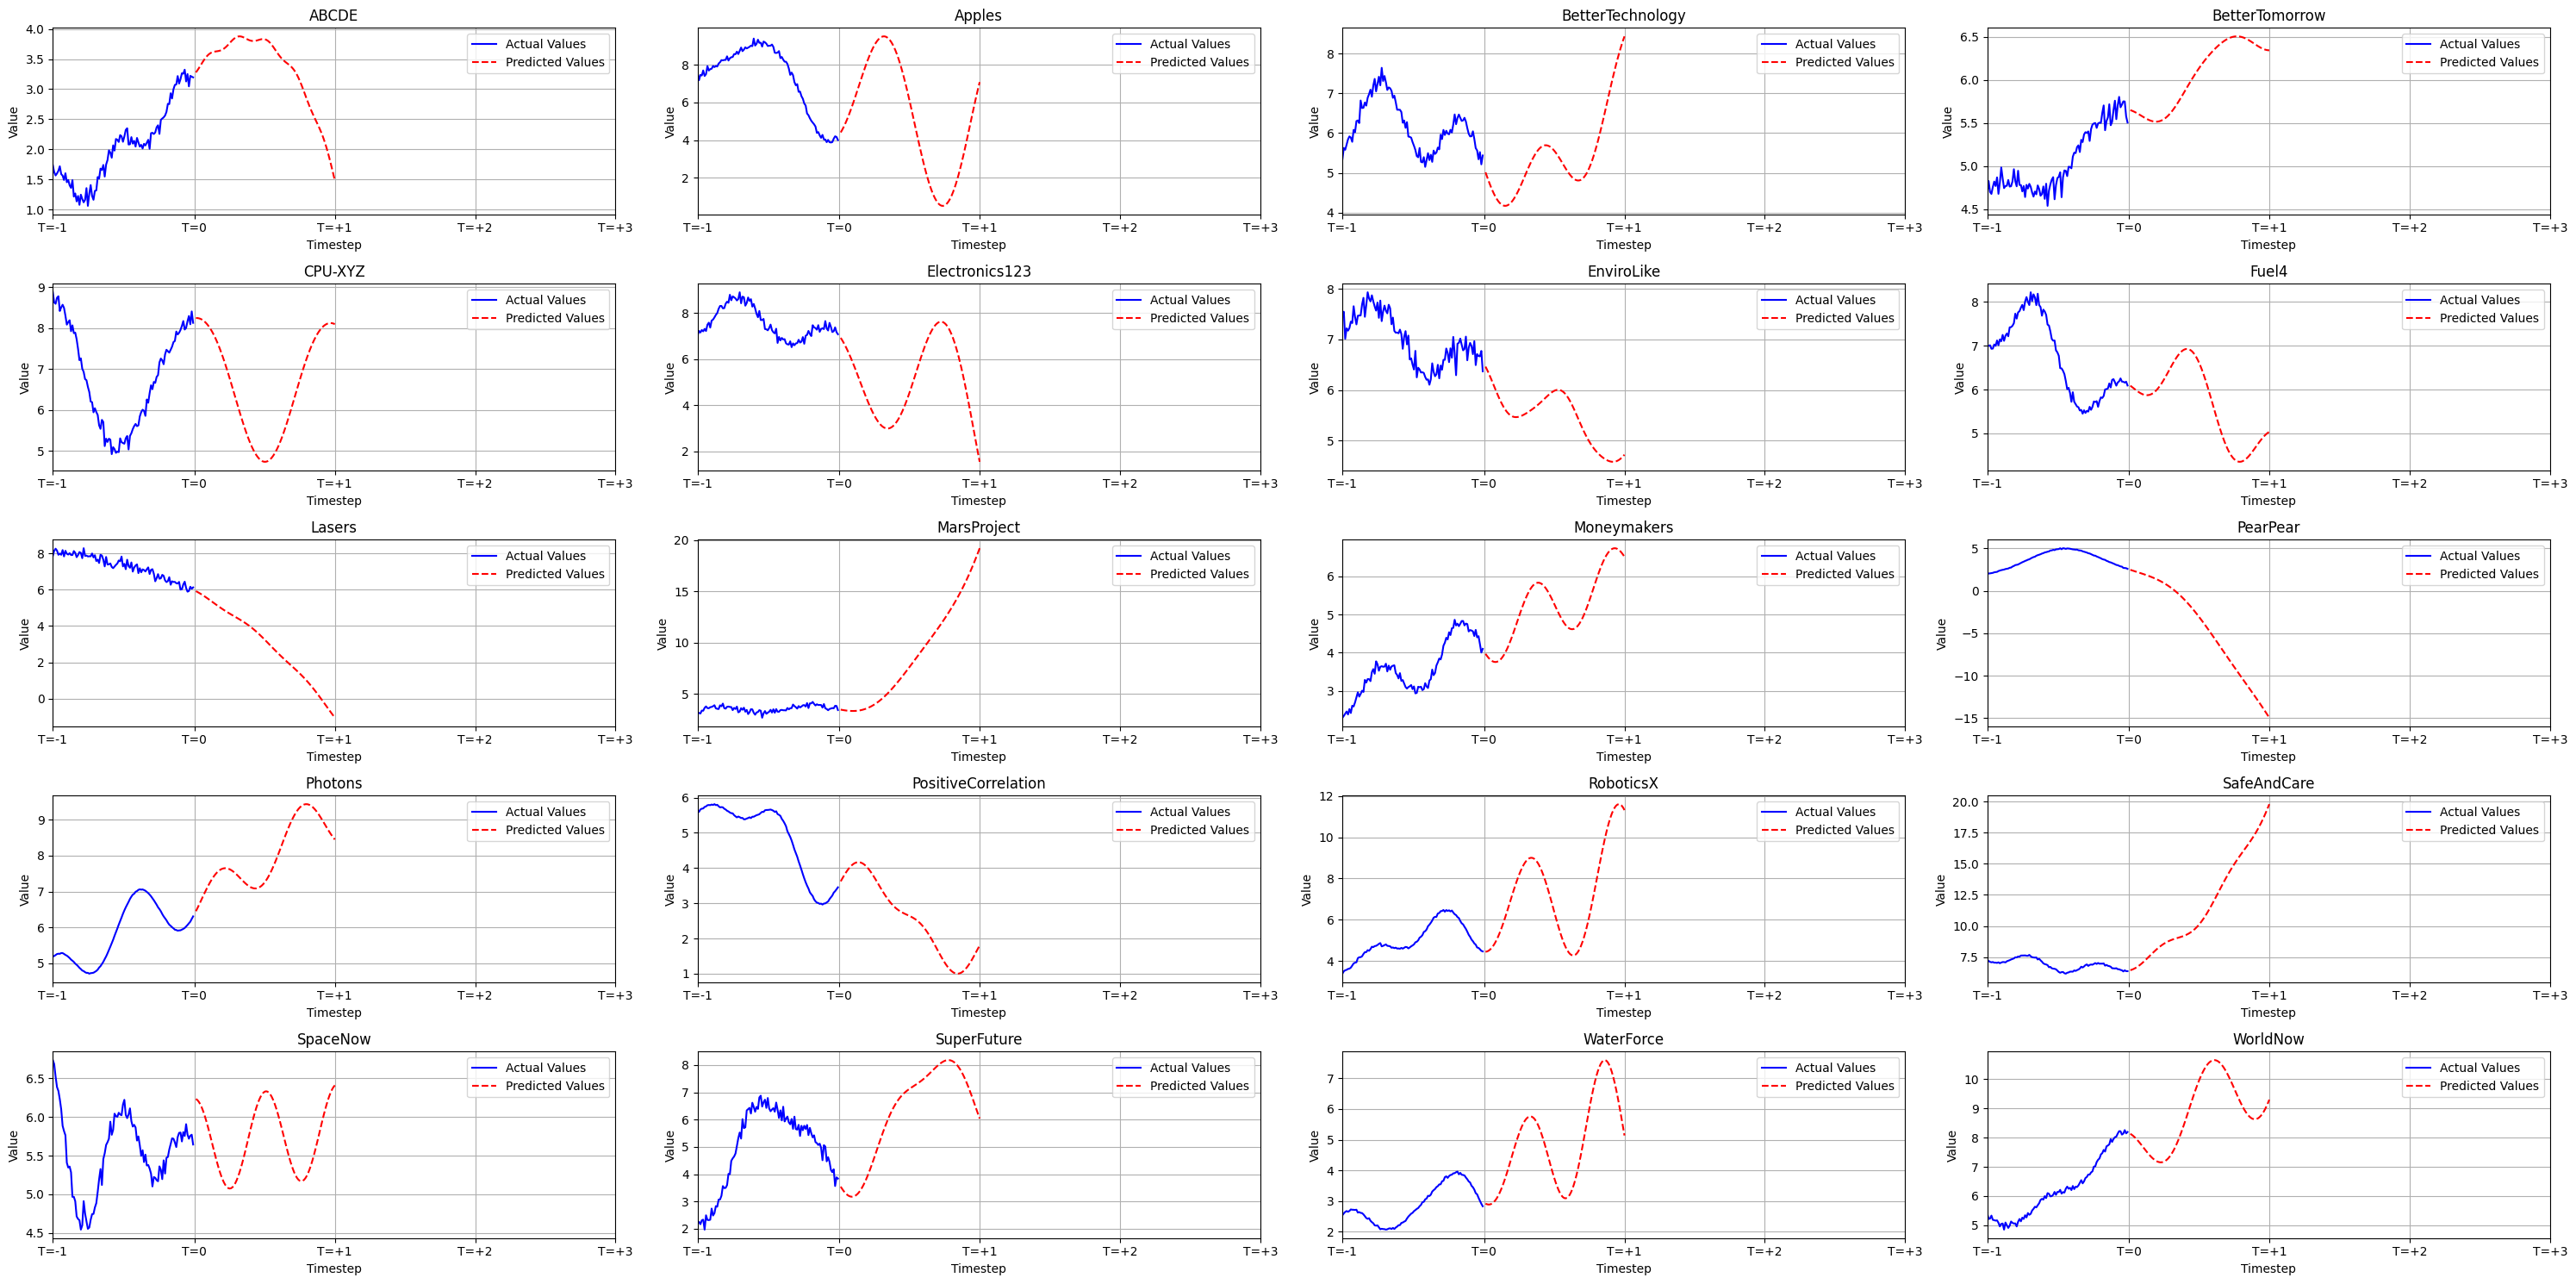

In [7]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.train_complex_sinusoidal()
complex_sinusoidal_predictions = RMC.predict_complex_sinusoidal()
RMC.plot_predictions(val_range=201, predictions=complex_sinusoidal_predictions, figsize=(30, 15))

## ARIMA

Lags for company = ABCDE


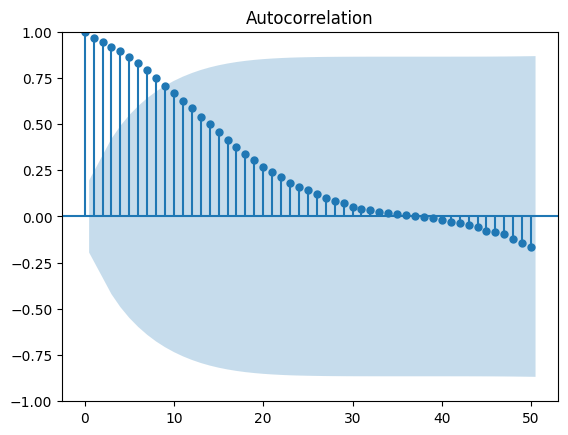

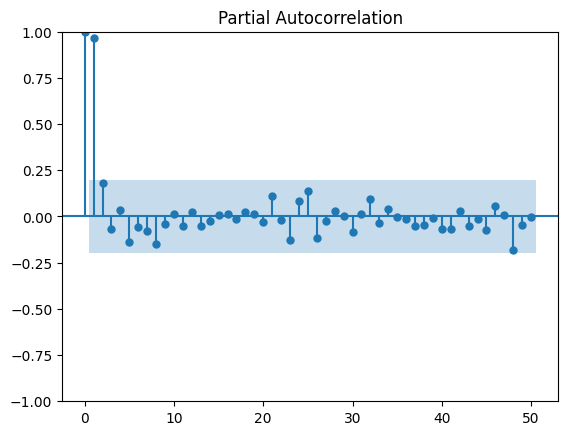

Lags for company = Apples


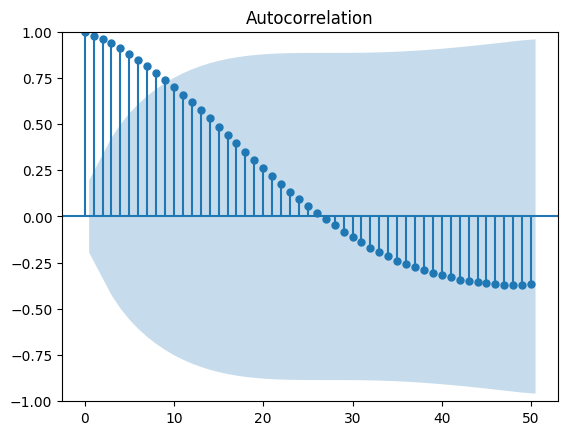

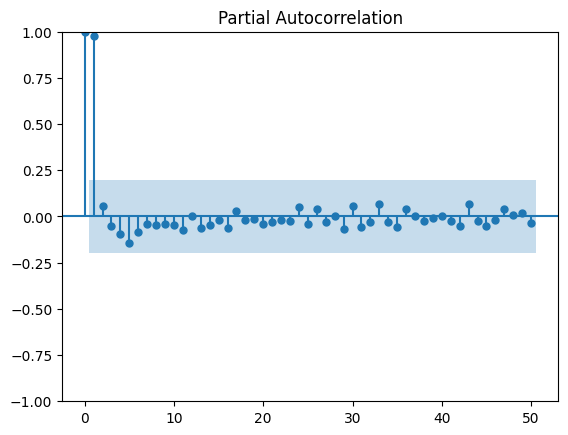

Lags for company = BetterTechnology


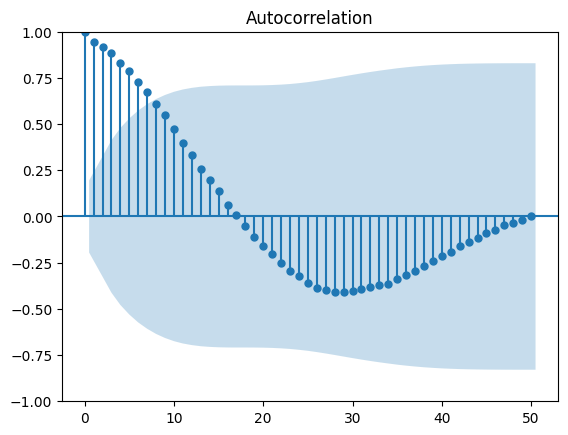

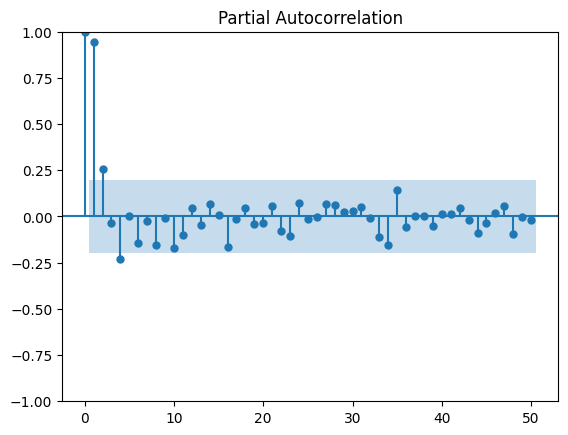

Lags for company = BetterTomorrow


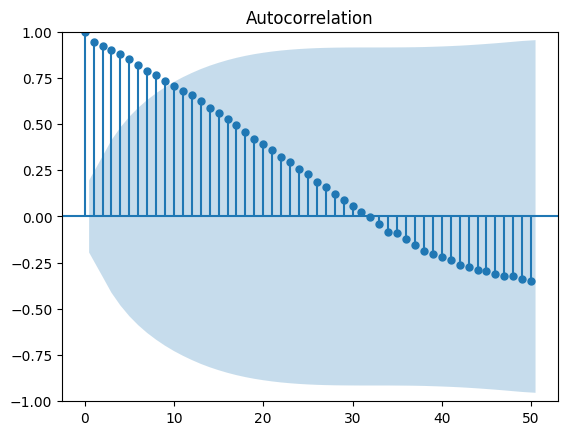

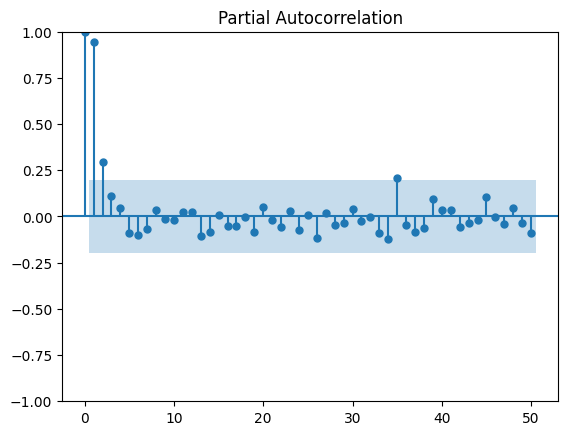

Lags for company = CPU-XYZ


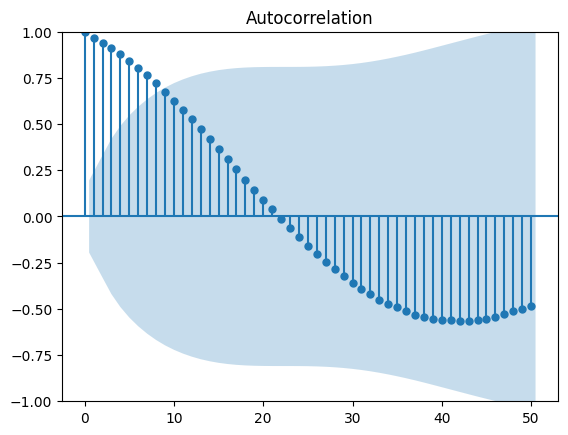

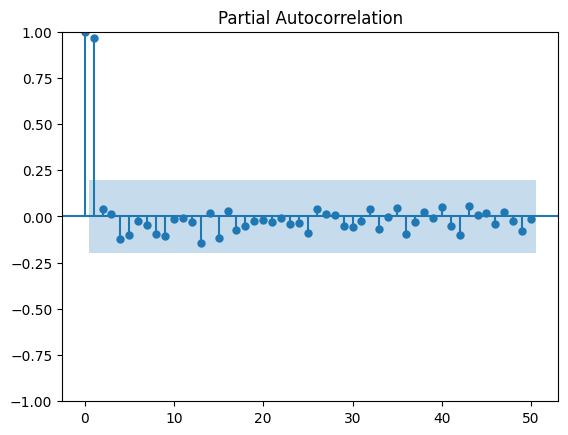

Lags for company = Electronics123


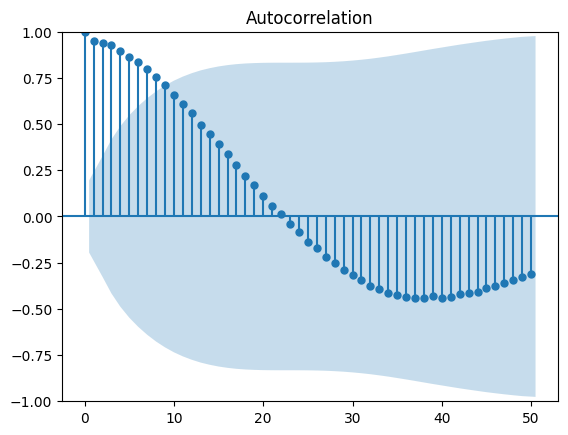

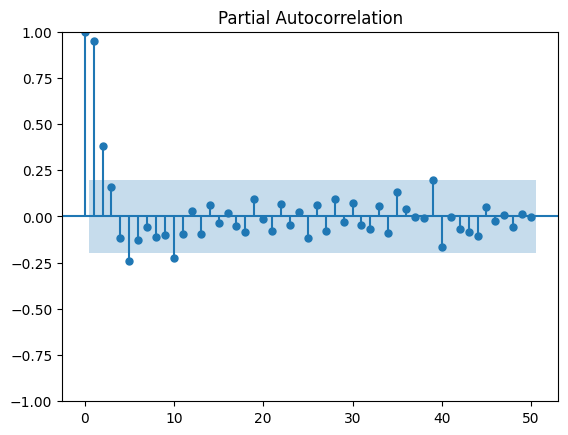

Lags for company = EnviroLike


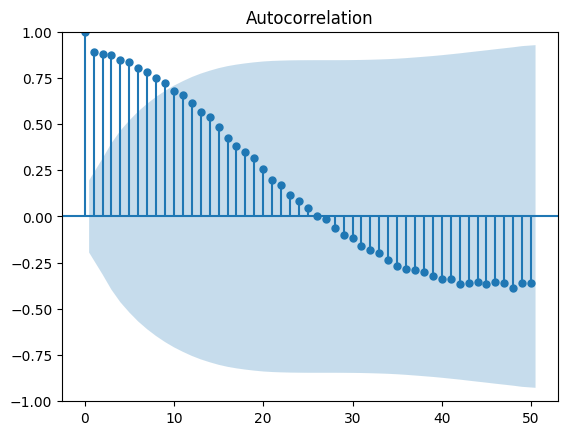

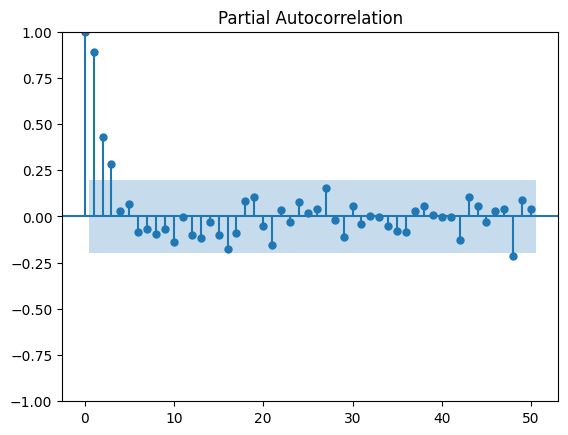

Lags for company = Fuel4


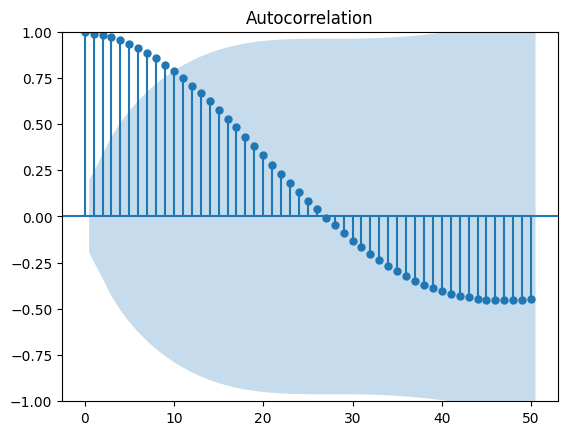

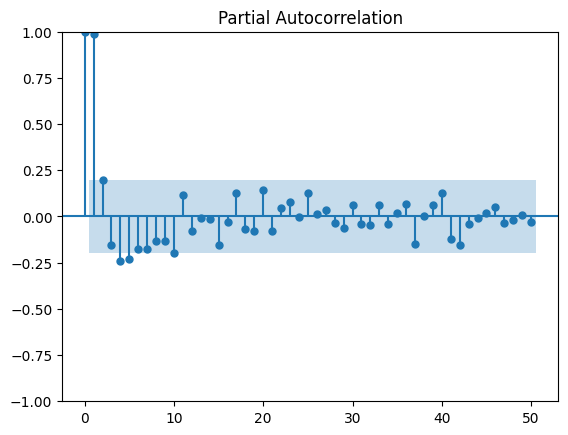

Lags for company = Lasers


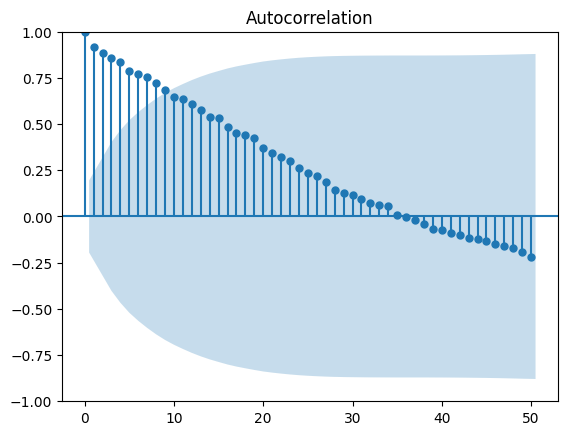

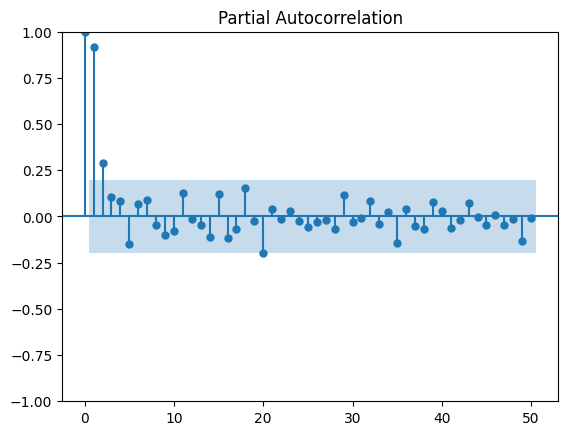

Lags for company = MarsProject


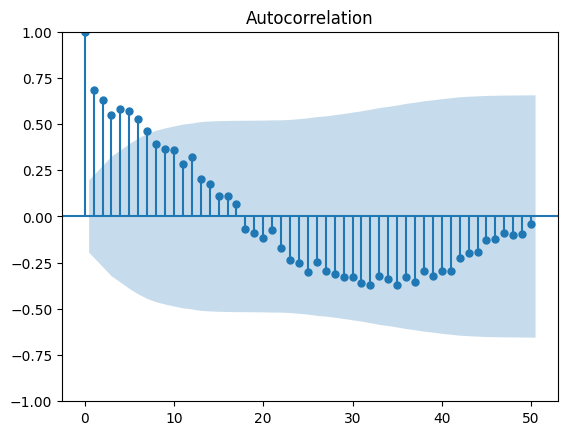

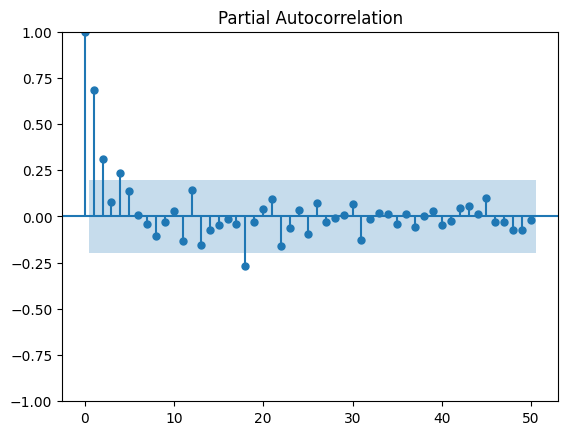

Lags for company = Moneymakers


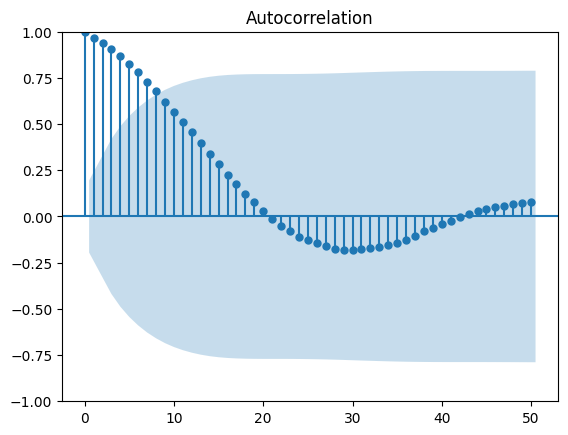

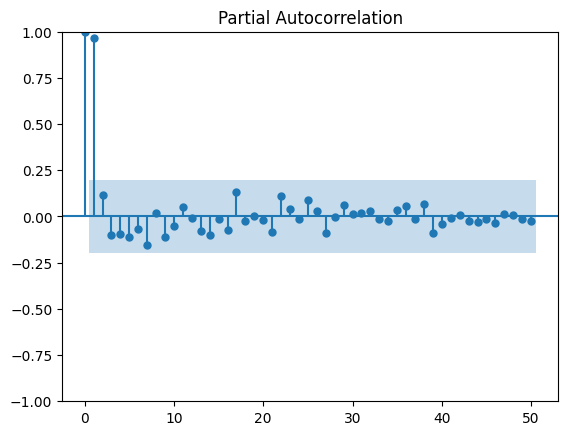

Lags for company = PearPear


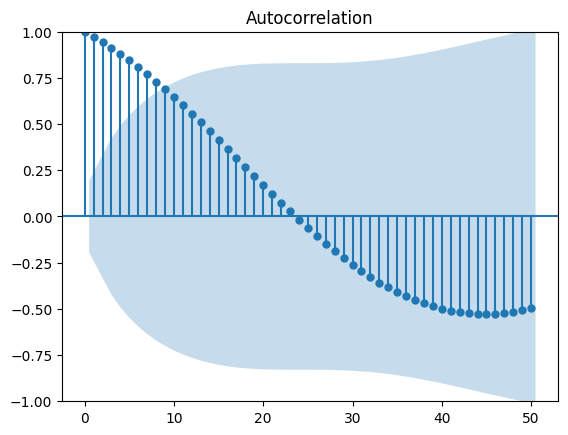

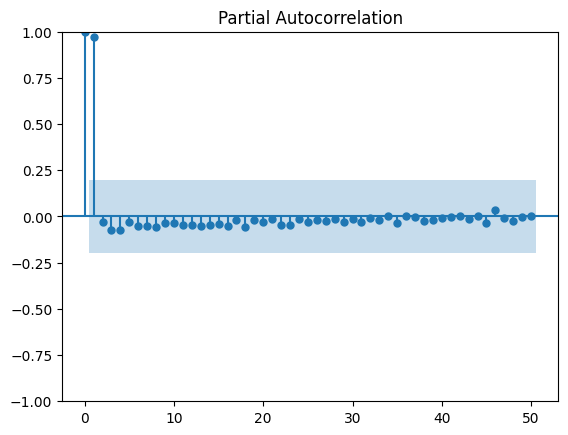

Lags for company = Photons


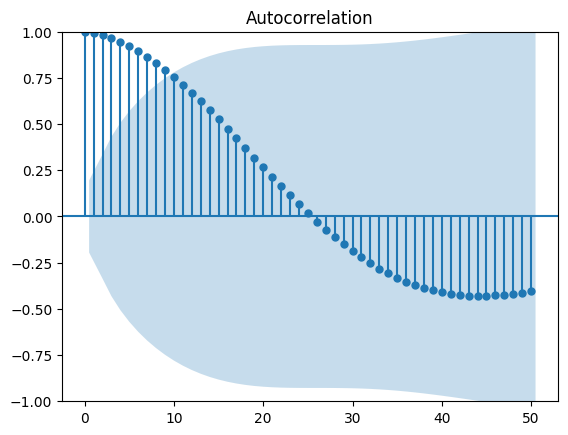

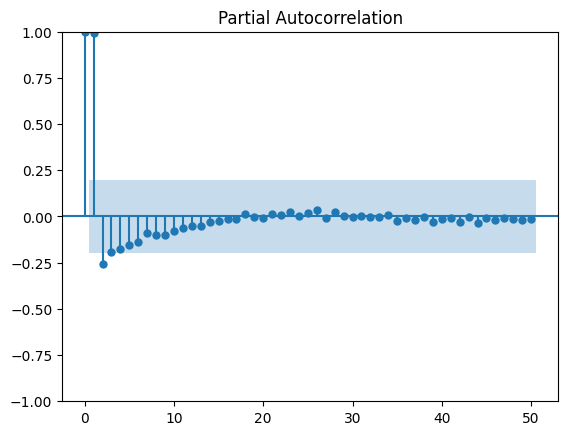

Lags for company = PositiveCorrelation


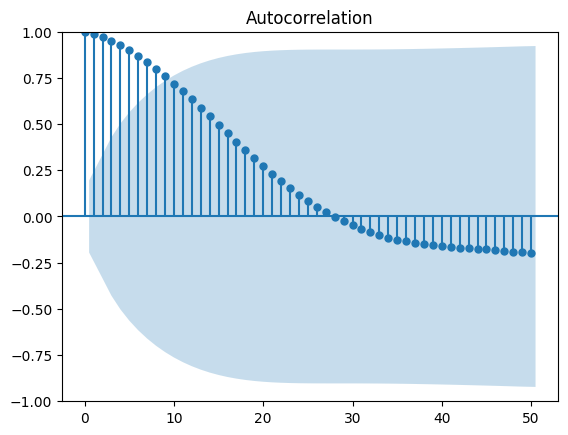

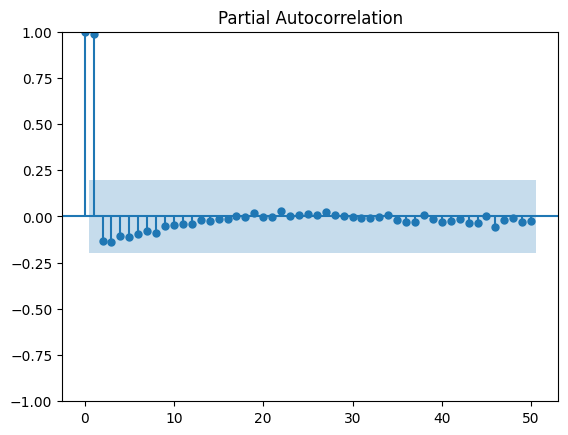

Lags for company = RoboticsX


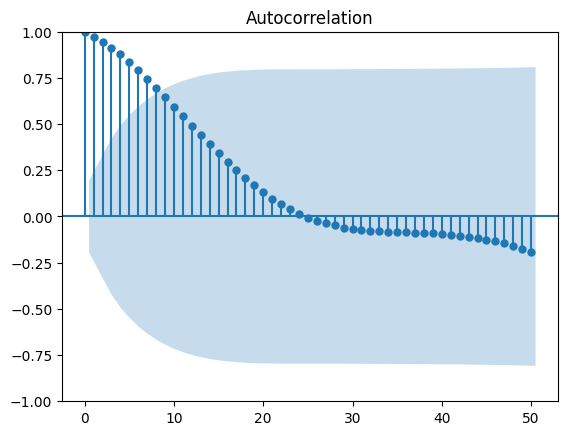

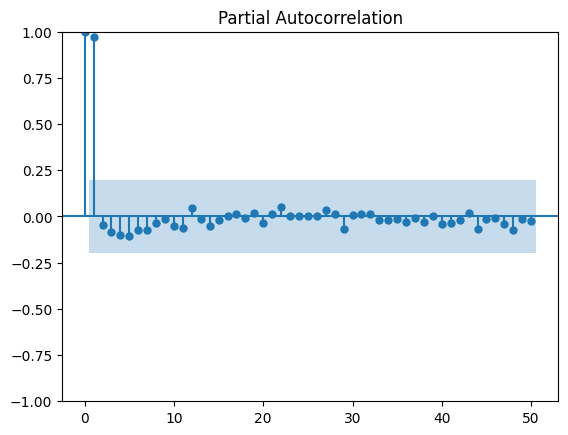

Lags for company = SafeAndCare


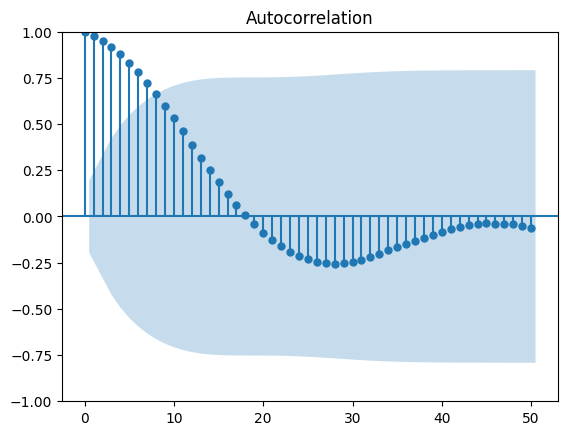

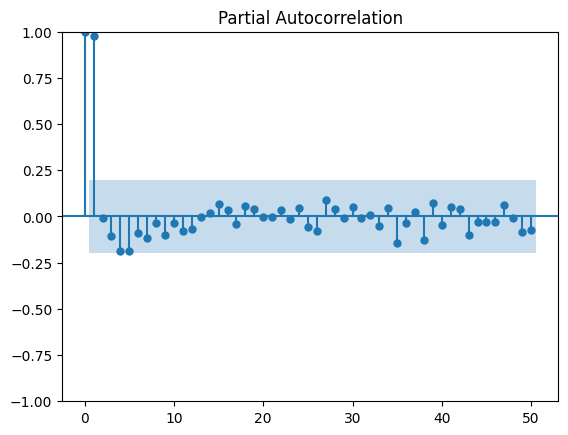

Lags for company = SpaceNow


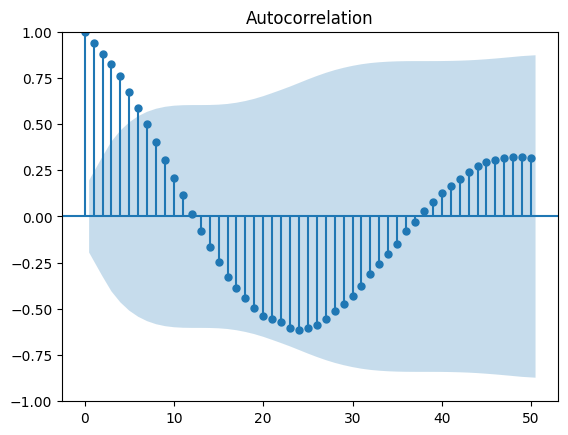

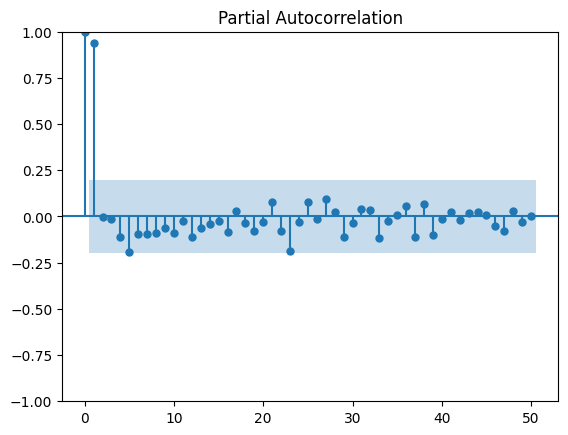

Lags for company = SuperFuture


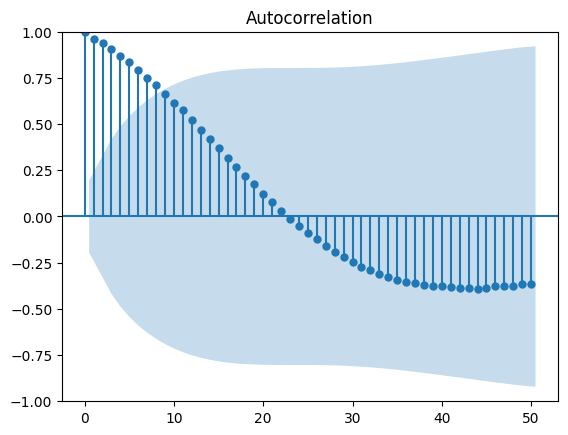

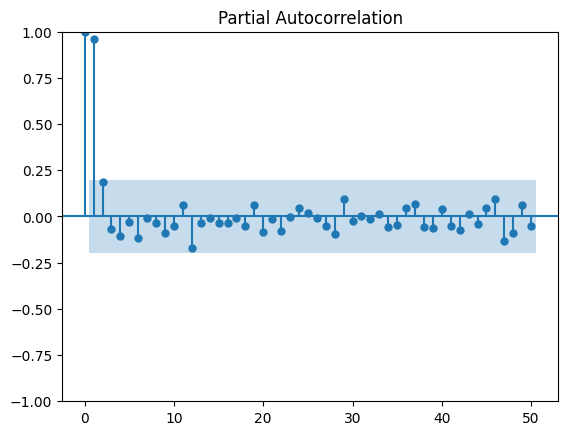

Lags for company = WaterForce


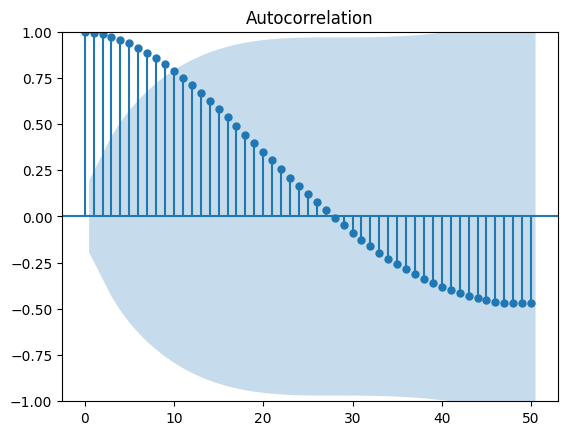

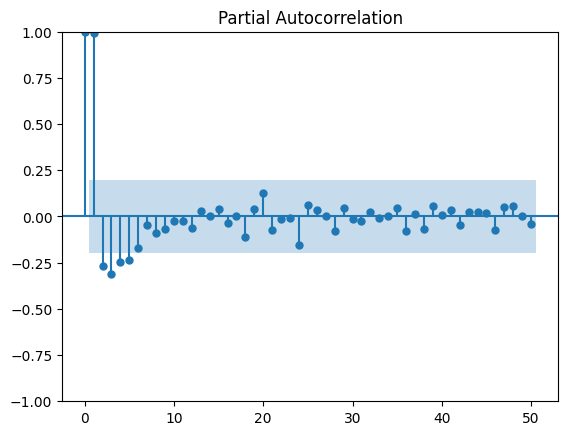

Lags for company = WorldNow


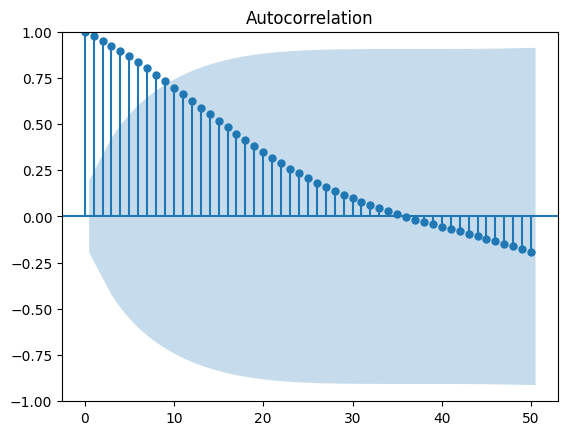

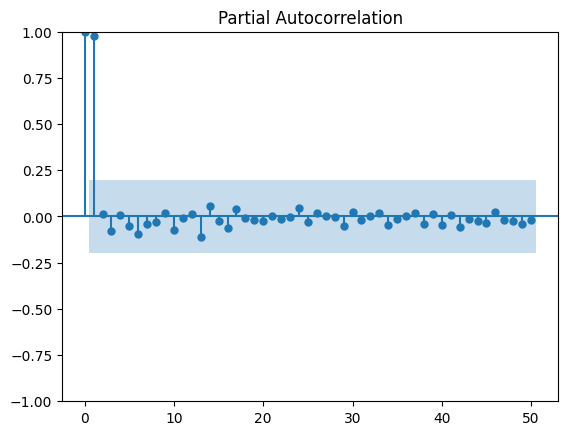

d:\MOO\MOO_env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
d:\MOO\MOO_env\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
d:\MOO\MOO_env\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


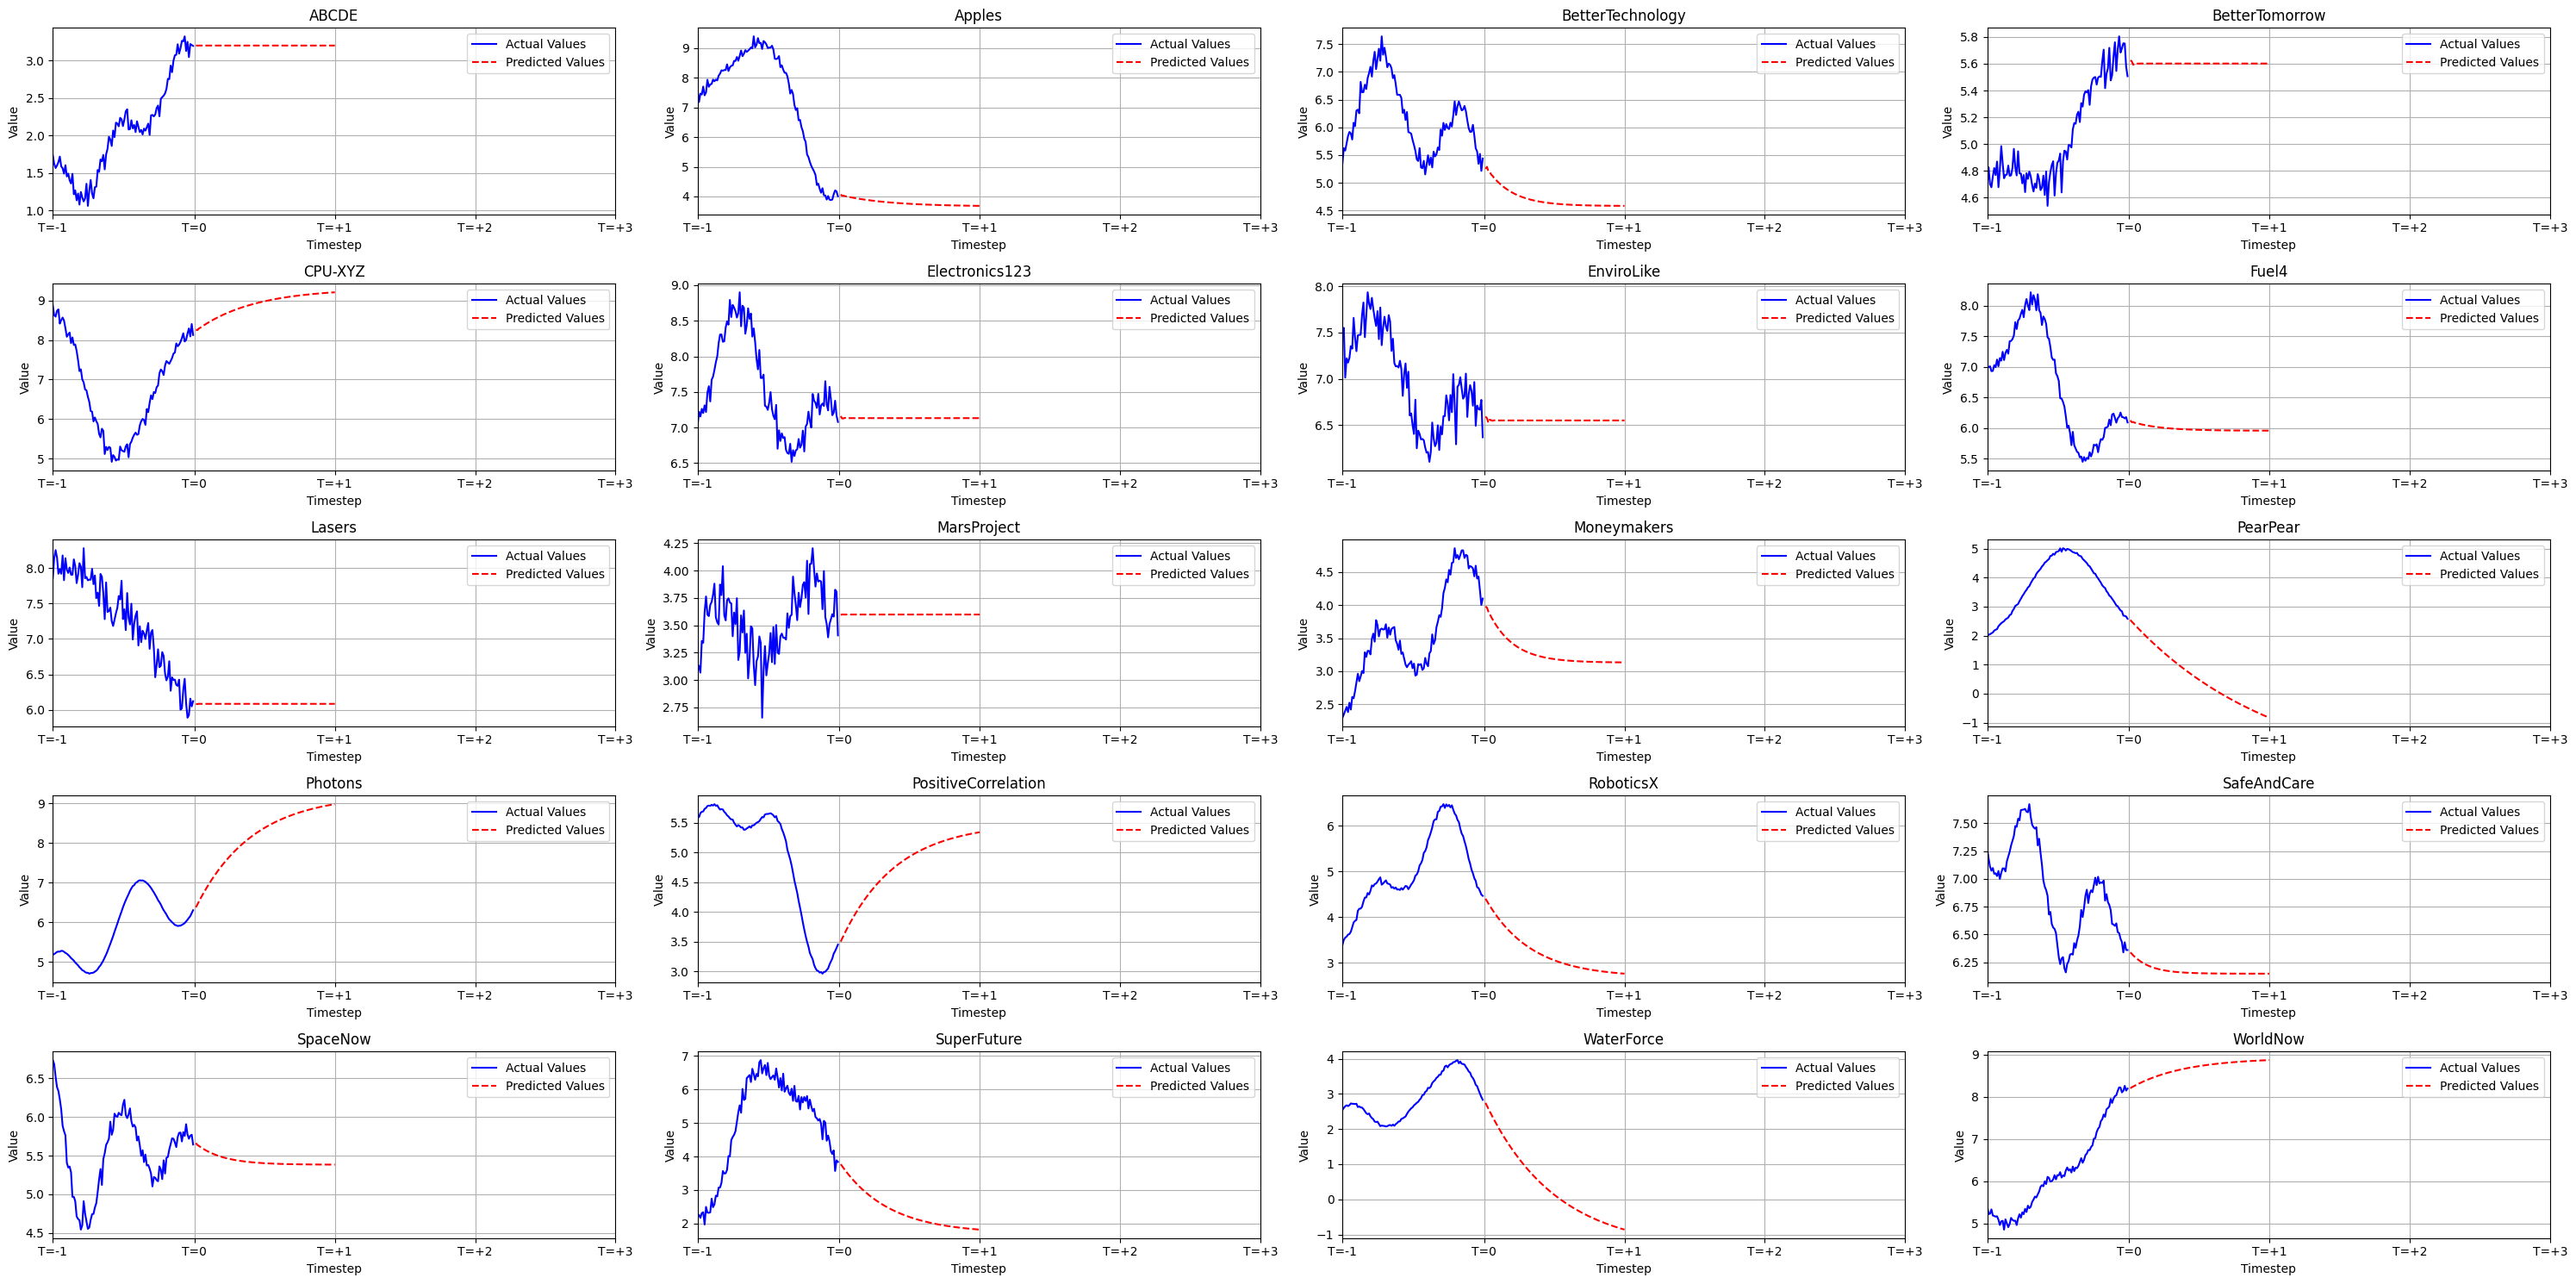

In [8]:
RMC = RegressionModelsCombined(data)
RMC.create_X_y(101)
RMC.plot_arima_lags(max_lags=50)
RMC.train_arima(p=2, d=1, q=1)
ARIMA_predictions = RMC.predict_arima()
RMC.plot_predictions(val_range=201, predictions=ARIMA_predictions, figsize=(30, 15))

### XGBoost

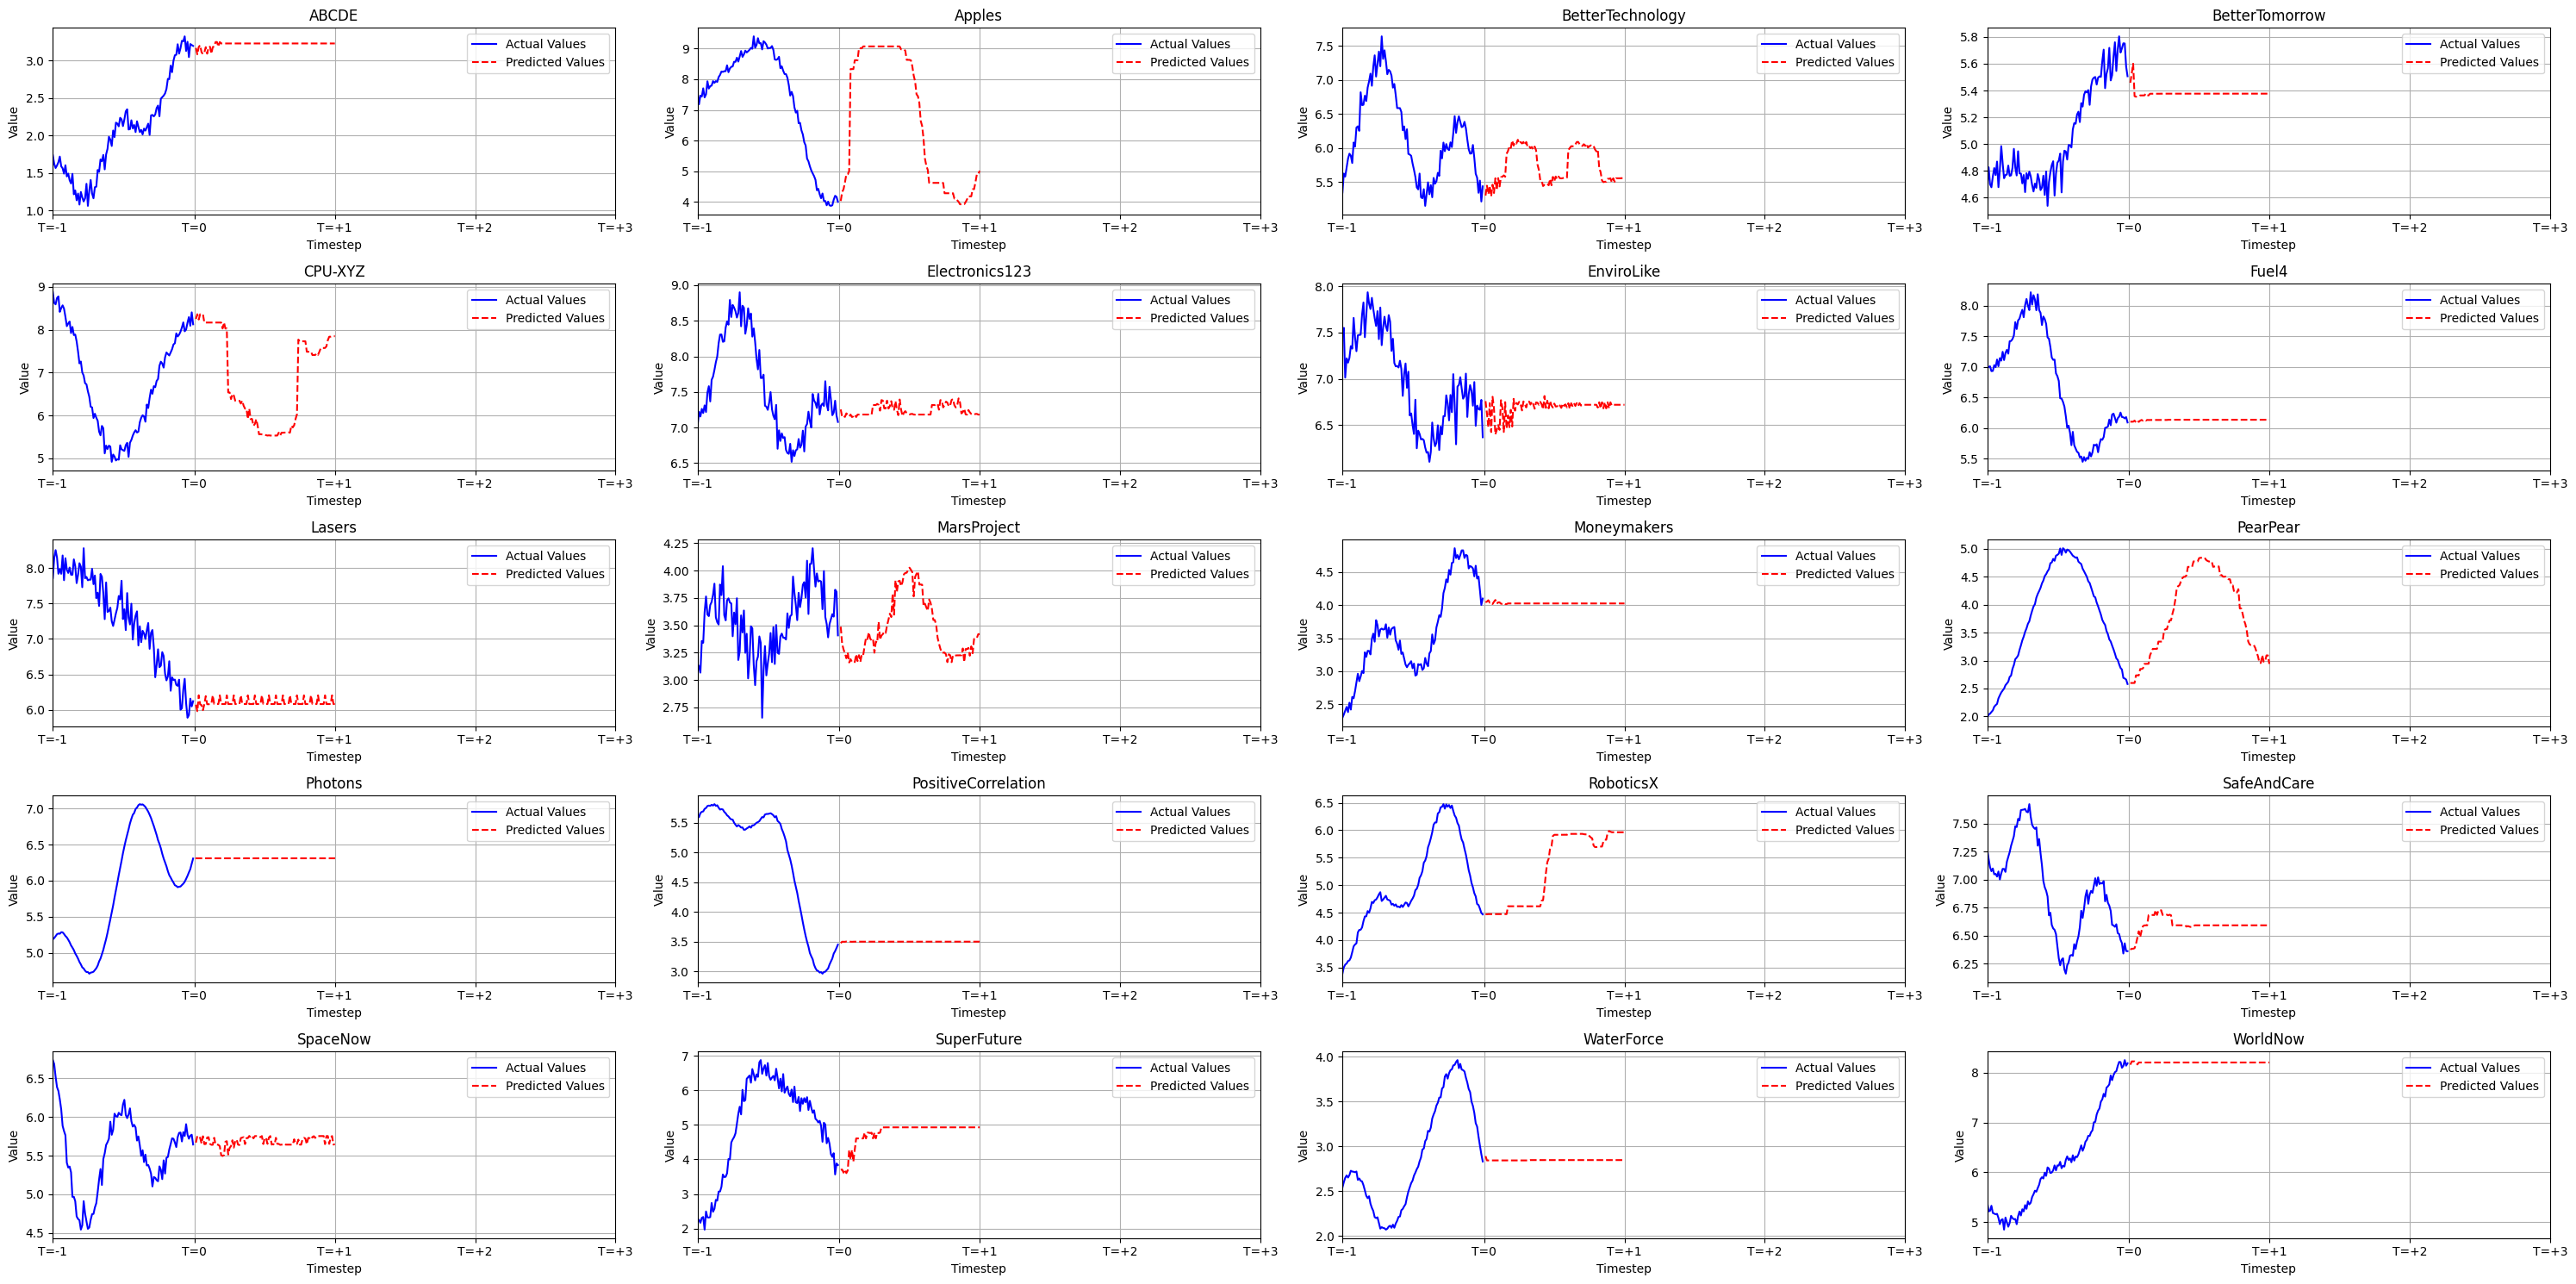

In [9]:
RMC = RegressionModelsCombined(data, window_size=50)
RMC.create_X_y_windows()
RMC.train_xgboost()
XGBoost_predictions = RMC.predict_xgboost()
RMC.plot_predictions(val_range=201, predictions=XGBoost_predictions, figsize=(30, 15))

### NODE

Using device: cpu
Company: ABCDE, Epoch 0, Loss: 1.5695128440856934
Company: ABCDE, Epoch 100, Loss: 0.04878316447138786
Company: ABCDE, Epoch 200, Loss: 0.044680435210466385
Company: Apples, Epoch 0, Loss: 56.299129486083984
Company: Apples, Epoch 100, Loss: 0.18476903438568115
Company: Apples, Epoch 200, Loss: 0.08147437125444412
Company: BetterTechnology, Epoch 0, Loss: 51.127159118652344
Company: BetterTechnology, Epoch 100, Loss: 0.2391645908355713
Company: BetterTechnology, Epoch 200, Loss: 0.2078106701374054
Company: BetterTomorrow, Epoch 0, Loss: 13.545938491821289
Company: BetterTomorrow, Epoch 100, Loss: 0.028459083288908005
Company: BetterTomorrow, Epoch 200, Loss: 0.01850772090256214
Company: CPU-XYZ, Epoch 0, Loss: 57.053436279296875
Company: CPU-XYZ, Epoch 100, Loss: 1.248752236366272
Company: CPU-XYZ, Epoch 200, Loss: 0.4138222634792328
Company: Electronics123, Epoch 0, Loss: 22.29977798461914
Company: Electronics123, Epoch 100, Loss: 0.31149664521217346
Company: Electro

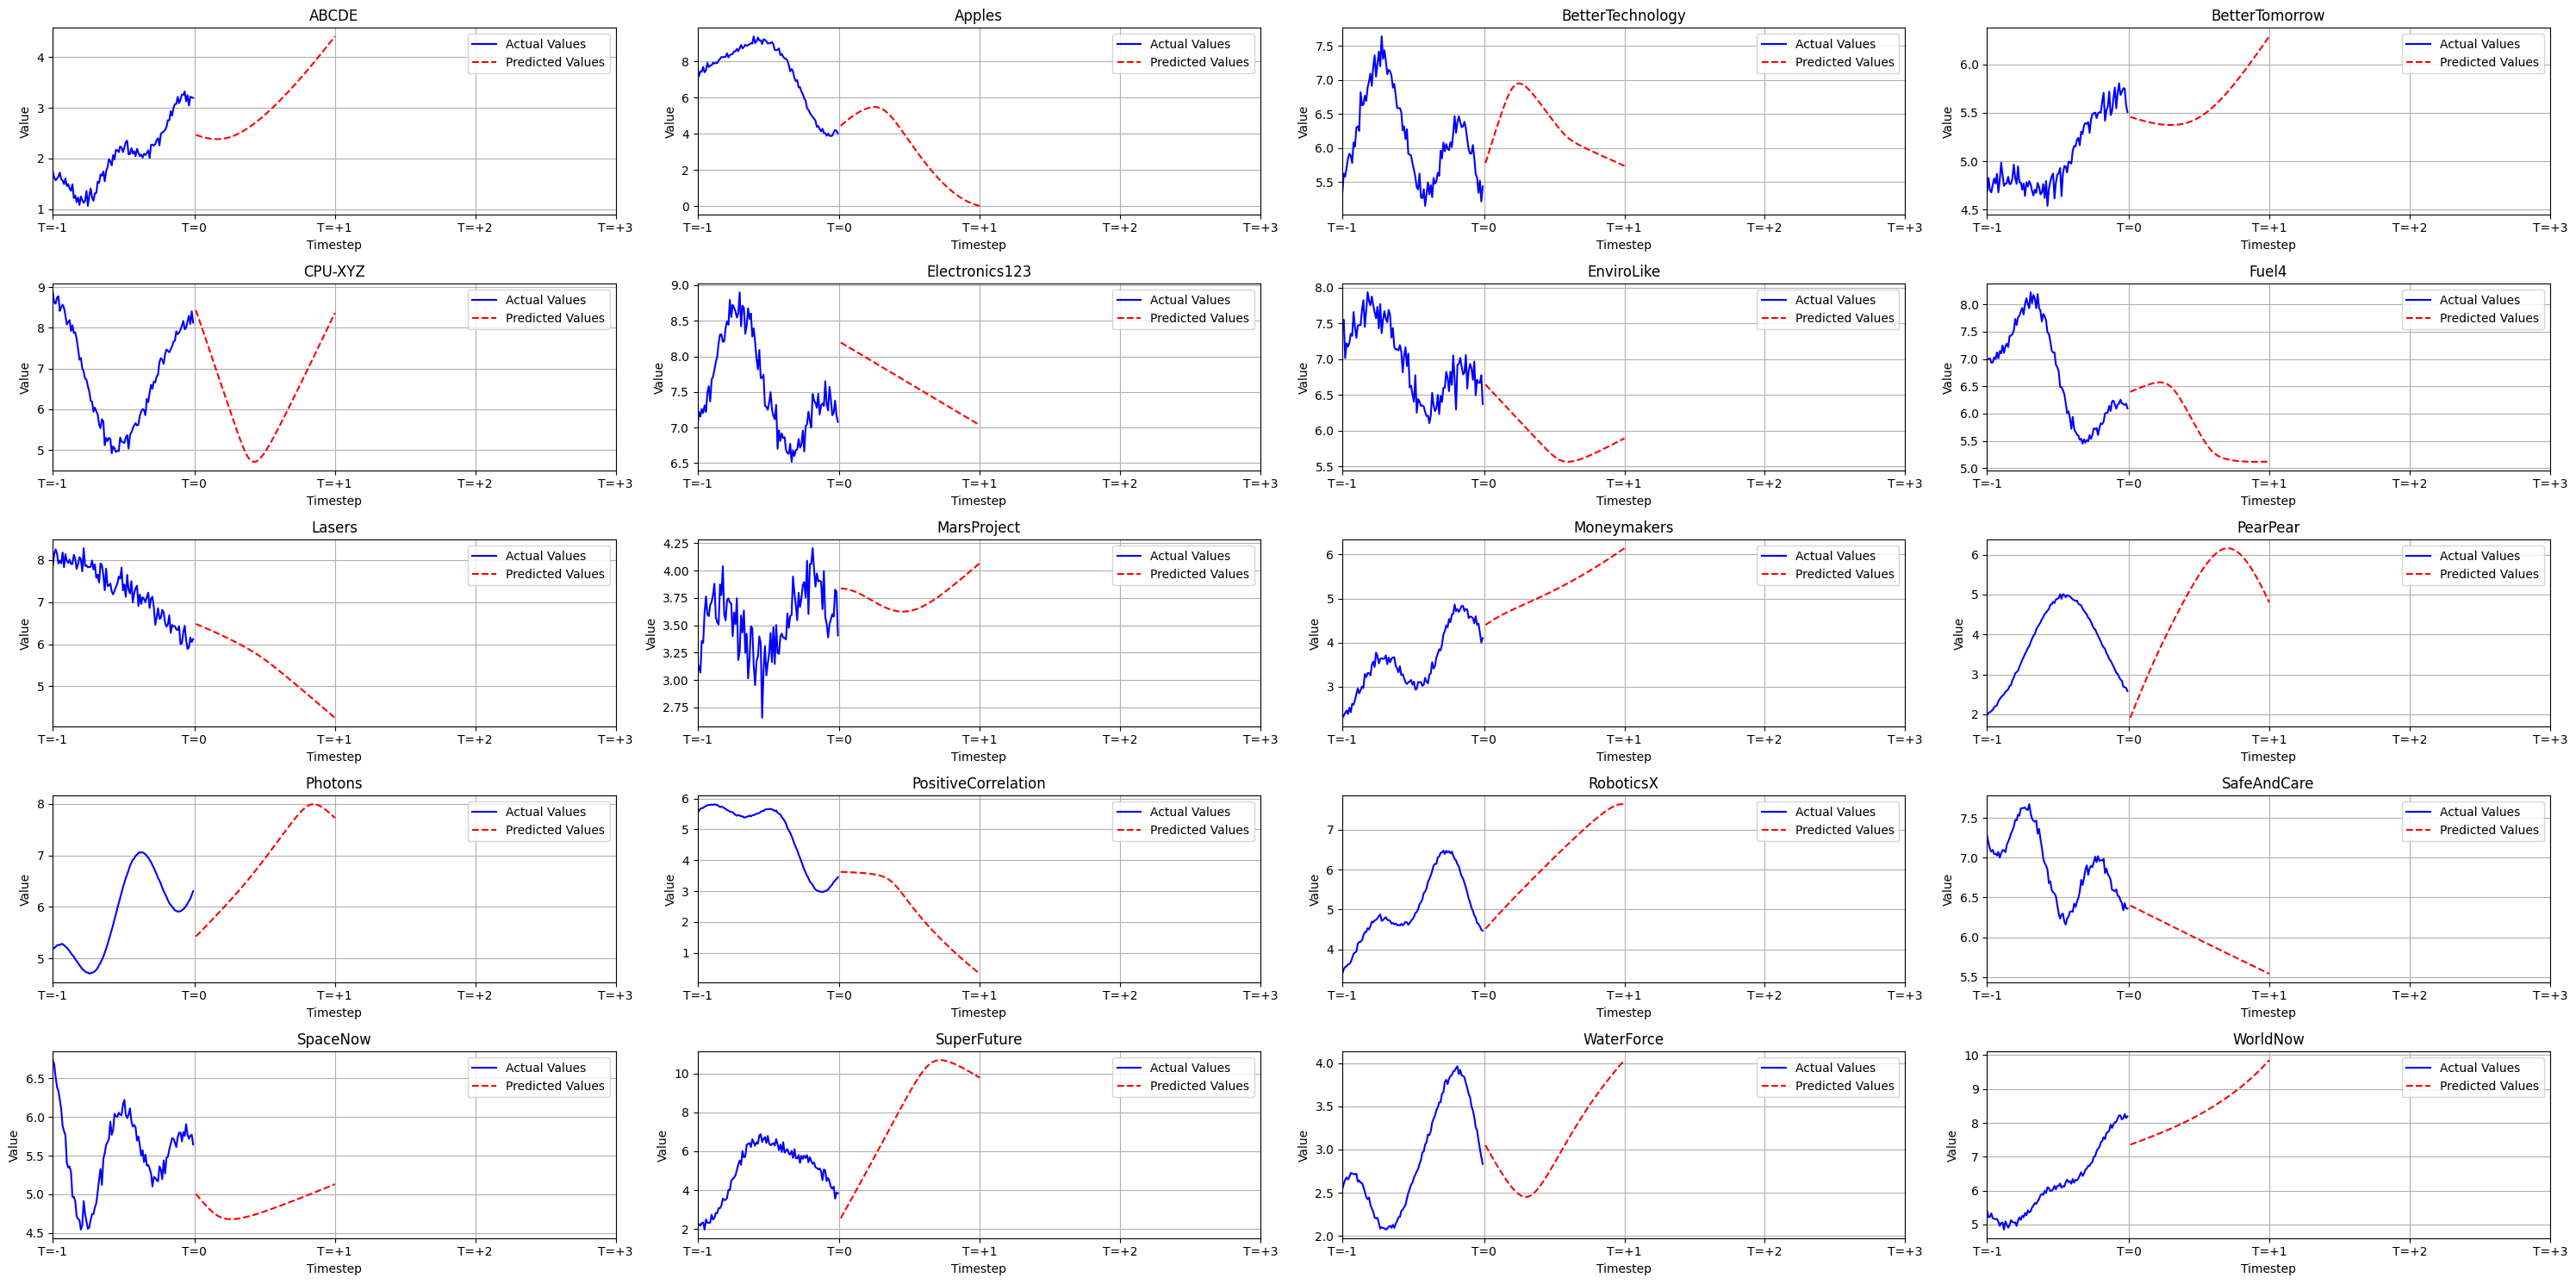

In [10]:
RMC = RegressionModelsCombined(data, window_size=50)
RMC.train_NODE()
NODE_predictions = RMC.predict_NODE()
RMC.plot_predictions(val_range=201, predictions=NODE_predictions, figsize=(30, 15))

## Single-Run WSM Run

In [11]:
risks = RMC.get_covariance_matrix()
solver = Solver(data, NODE_predictions, risks)

     pcost       dcost       gap    pres   dres
 0:  2.3673e-03 -2.1485e+01  2e+01  2e-16  1e-15
 1:  2.0112e-03 -5.8263e-01  6e-01  1e-16  1e-15
 2:  8.6789e-04 -4.5988e-02  5e-02  1e-16  2e-16
 3:  3.5654e-04 -2.3546e-03  3e-03  2e-16  2e-16
 4:  2.2341e-04 -8.6686e-05  3e-04  1e-16  2e-16
 5:  1.8355e-04  1.4679e-04  4e-05  1e-16  1e-16
 6:  1.7698e-04  1.7532e-04  2e-06  1e-16  1e-16
 7:  1.7640e-04  1.7634e-04  6e-08  1e-16  2e-16
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -3.1277e+00 -3.2311e+01  2e+02  2e+00  4e-16
 1: -1.0060e+00 -1.4506e+01  2e+01  8e-02  7e-16
 2: -8.7474e-01 -2.9474e+00  2e+00  1e-02  2e-15
 3: -1.4019e+00 -1.8018e+00  4e-01  2e-05  7e-16
 4: -1.5472e+00 -1.5519e+00  5e-03  2e-07  4e-16
 5: -1.5487e+00 -1.5488e+00  5e-05  2e-09  6e-16
 6: -1.5487e+00 -1.5487e+00  5e-07  2e-11  5e-16
Optimal solution found.


In [12]:
solutions = solver.solve_wsm()

Running for w1=0.0, w2=1.0
     pcost       dcost       gap    pres   dres
 0: -7.8909e-01 -2.6512e+01  1e+02  2e+00  7e-16
 1: -2.6827e-01 -1.0076e+01  1e+01  2e-02  1e-15
 2: -2.9906e-01 -2.3399e+00  2e+00  4e-03  9e-16
 3: -5.5796e-01 -1.3577e+00  8e-01  2e-04  8e-16
 4: -7.5327e-01 -7.7162e-01  2e-02  3e-06  9e-16
 5: -7.6163e-01 -7.6182e-01  2e-04  3e-08  6e-16
 6: -7.6172e-01 -7.6172e-01  2e-06  3e-10  6e-16
 7: -7.6172e-01 -7.6172e-01  2e-08  3e-12  6e-16
Optimal solution found.
Running for w1=0.1, w2=0.9
     pcost       dcost       gap    pres   dres
 0: -4.6525e-01 -2.4900e+01  1e+02  2e+00  1e-15
 1: -2.0791e-01 -9.0691e+00  9e+00  2e-02  2e-15
 2: -2.2770e-01 -1.8874e+00  2e+00  3e-03  1e-15
 3: -4.2920e-01 -1.0045e+00  6e-01  2e-16  5e-16
 4: -5.3873e-01 -5.7556e-01  4e-02  2e-16  8e-16
 5: -5.5927e-01 -5.5974e-01  5e-04  2e-16  4e-16
 6: -5.5957e-01 -5.5958e-01  5e-06  2e-16  4e-16
 7: -5.5958e-01 -5.5958e-01  5e-08  2e-16  4e-16
Optimal solution found.
Running for w1=0.2

In [13]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,1.548724,2.033381,1.000000e+00,2.363103e-10,7.762472e-10,6.066328e-10,7.958368e-10,5.493022e-10,5.986013e-10,2.523589e-10,...,1.034868e-09,5.077688e-10,7.676077e-10,6.326693e-10,1.025300e-09,4.324759e-10,9.787184e-10,5.259543e-10,7.230913e-10,1.0
1,1.548724,2.033381,9.999999e-01,1.012603e-09,3.180143e-09,3.494004e-09,2.777608e-09,2.777446e-09,1.593649e-09,1.398093e-09,...,7.510713e-09,3.045325e-09,5.224347e-09,2.000636e-08,7.530851e-09,2.643285e-09,7.891685e-09,3.193257e-09,4.077062e-09,1.0
2,1.287689,1.013862,8.281992e-01,9.612174e-10,2.128177e-09,2.451075e-09,2.156491e-09,1.977412e-09,3.953390e-09,1.165474e-09,...,3.565514e-09,2.211121e-09,3.054577e-09,1.718007e-01,3.960471e-09,1.923797e-09,3.582141e-09,2.175629e-09,2.521016e-09,1.0
3,1.051113,0.419096,6.724972e-01,7.080067e-09,6.634536e-09,2.858311e-08,1.008241e-08,1.006850e-08,3.556842e-08,7.605294e-09,...,3.348343e-08,2.668126e-08,3.419710e-08,3.275024e-01,4.493589e-08,1.699328e-08,3.798078e-08,1.712346e-08,1.429074e-08,1.0
4,0.932826,0.239101,5.946463e-01,1.437449e-08,4.004902e-09,6.591701e-08,7.019442e-09,1.106809e-08,5.712239e-08,1.524796e-08,...,9.107089e-09,8.688270e-08,2.950078e-08,4.053532e-01,1.081882e-08,4.047299e-08,6.554274e-09,2.774460e-08,1.081161e-08,1.0
5,0.861854,0.168669,5.479359e-01,8.211287e-10,2.701144e-11,1.022947e-08,4.584029e-11,1.295847e-10,1.421755e-09,6.116703e-10,...,6.279359e-11,9.733449e-08,5.087649e-10,4.520640e-01,5.380840e-11,4.640720e-09,3.446502e-11,8.920835e-10,9.394676e-11,1.0
6,0.754384,0.099364,4.858097e-01,3.195168e-09,4.008524e-10,4.579993e-09,7.758450e-10,1.054690e-09,1.772363e-08,2.260933e-09,...,8.931291e-10,6.923368e-02,2.806033e-09,4.449566e-01,1.482213e-09,3.339793e-08,1.302585e-09,2.102766e-09,9.908080e-10,1.0
7,0.646148,0.053352,4.293576e-01,1.864020e-09,1.830892e-10,1.593833e-09,4.142681e-10,4.645144e-10,8.952885e-07,1.067692e-09,...,3.649384e-10,9.692898e-02,9.670968e-10,4.221832e-01,6.048294e-10,5.152934e-02,5.758490e-10,6.705114e-10,4.310875e-10,1.0
8,0.522331,0.020173,2.386035e-01,5.466338e-09,3.806327e-10,2.312629e-09,6.600164e-10,7.179391e-10,2.006859e-01,1.516197e-09,...,6.986120e-10,1.474167e-01,1.655595e-09,3.871284e-01,1.224523e-09,2.616543e-02,1.066999e-09,1.438264e-09,7.774921e-10,1.0
9,0.424099,0.006083,8.086034e-02,1.603380e-09,1.400241e-10,1.448231e-09,3.290481e-10,4.958699e-10,3.697914e-01,8.970035e-10,...,2.362357e-10,1.902066e-01,7.350253e-10,3.591267e-01,3.646729e-10,1.504506e-05,3.909954e-10,6.012929e-10,3.342620e-10,1.0


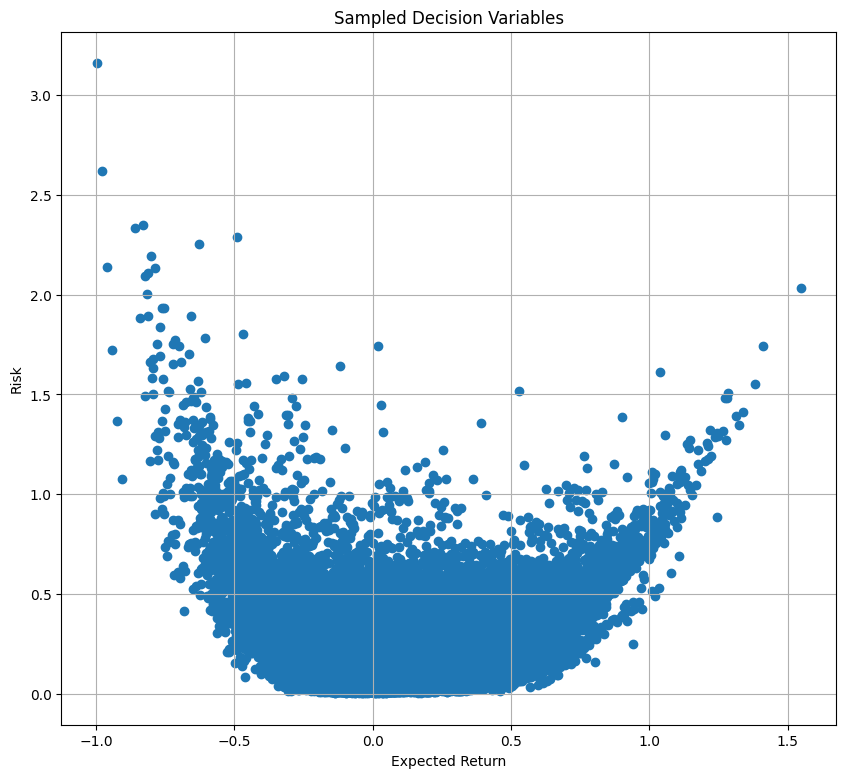

In [14]:
solver.plot_sampled_decision_variables(20, 0.2)

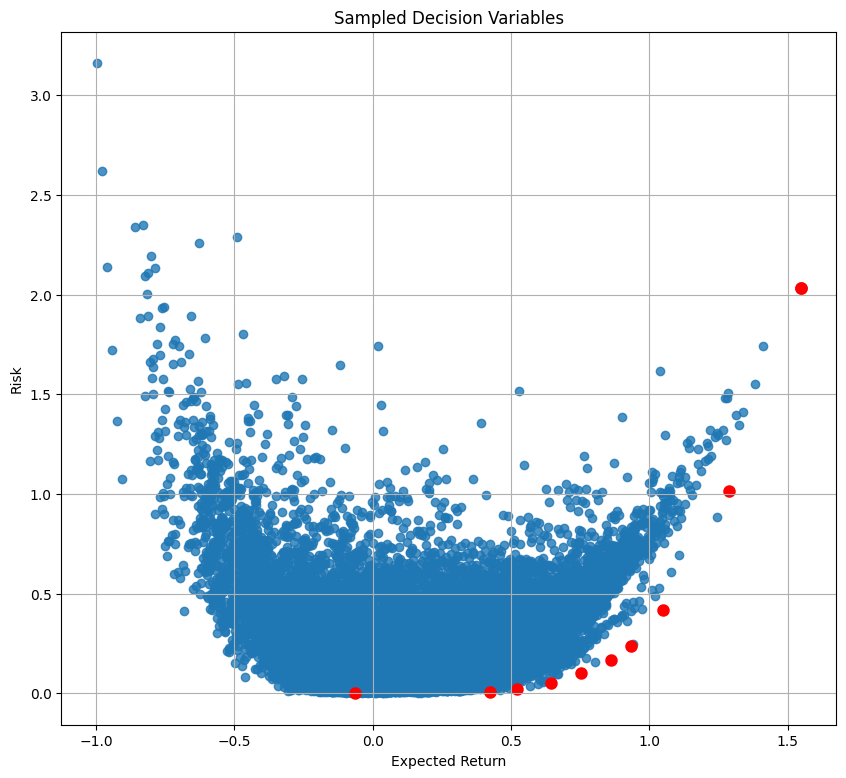

In [15]:
solver.plot_front(solutions, n=20, step=0.2)

### Single-Run ECM Algorithm

In [16]:
solutions = solver.solve_ecm()

Running for threshold=-0.06547116796763697
     pcost       dcost       gap    pres   dres
 0:  1.6023e-03 -2.2019e+01  8e+01  1e+00  5e+00
 1:  6.7045e-02 -7.6597e+00  9e+00  3e-02  1e-01
 2:  2.6409e-02 -3.9753e-01  4e-01  1e-03  3e-03
 3:  2.3840e-03 -1.2391e-01  1e-01  1e-16  3e-16
 4:  1.1812e-03 -1.5254e-02  2e-02  2e-16  2e-16
 5:  5.1498e-04 -1.8706e-03  2e-03  2e-16  2e-16
 6:  2.4197e-04 -4.7226e-04  7e-04  1e-16  1e-16
 7:  1.9407e-04  1.0022e-04  9e-05  1e-16  1e-16
 8:  1.7828e-04  1.7255e-04  6e-06  2e-16  1e-16
 9:  1.7649e-04  1.7616e-04  3e-07  2e-16  2e-16
10:  1.7639e-04  1.7636e-04  3e-08  1e-16  2e-16
Optimal solution found.
Running for threshold=0.09594836086890413
     pcost       dcost       gap    pres   dres
 0:  2.8290e-03 -2.1338e+01  8e+01  1e+00  5e+00
 1:  8.8939e-02 -7.6723e+00  9e+00  4e-02  1e-01
 2:  3.3167e-02 -3.9368e-01  4e-01  8e-04  3e-03
 3:  9.6292e-03 -8.7849e-02  1e-01  1e-04  5e-04
 4:  1.9228e-03 -4.3940e-02  5e-02  1e-05  4e-05
 5:  1.1411

In [17]:
pretty_display(solutions)

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
0,-0.064535,0.000176,9.563754e-08,3.345371e-07,1.040747e-01,2.686171e-02,1.304673e-01,1.977532e-02,1.512268e-07,1.823215e-01,...,4.161162e-02,8.311911e-02,7.146801e-03,4.371512e-02,1.611232e-03,3.563293e-07,8.026402e-02,1.479008e-01,3.827784e-02,1.0
1,0.095949,0.000387,6.637024e-07,1.211407e-07,2.246596e-03,5.392588e-02,2.169417e-01,2.792388e-02,1.064140e-01,3.973680e-02,...,9.986952e-05,1.566379e-01,1.305875e-02,1.277943e-01,7.699615e-07,3.957196e-04,3.467354e-03,1.083916e-01,5.373035e-02,1.0
2,0.257368,0.001219,6.936593e-08,2.725507e-08,3.756830e-08,4.105213e-02,1.227558e-01,1.179947e-02,2.999087e-01,2.210550e-07,...,4.444608e-08,2.124675e-01,5.406607e-06,2.573610e-01,1.015371e-07,1.334853e-02,5.850185e-08,5.587125e-04,2.866063e-02,1.0
3,0.418787,0.005630,7.344462e-02,9.341958e-08,4.882292e-08,5.949348e-07,1.098510e-07,1.476329e-07,3.772759e-01,1.454070e-07,...,8.861956e-08,1.916846e-01,2.356250e-07,3.575913e-01,1.111198e-07,9.732896e-07,1.235183e-07,1.242334e-07,1.290036e-07,1.0
4,0.580207,0.033536,3.336865e-01,2.668461e-08,3.460741e-09,4.358866e-08,5.955794e-09,6.860505e-09,9.785802e-02,1.462420e-08,...,8.158149e-09,1.205963e-01,2.136963e-08,4.035860e-01,1.246422e-08,4.427284e-02,1.059779e-08,1.392071e-08,8.262632e-09,1.0
5,0.741626,0.092784,4.785472e-01,2.521548e-09,3.435155e-10,1.761218e-09,7.435400e-10,8.241577e-10,1.922111e-08,1.714305e-09,...,6.973654e-10,7.835932e-02,1.802431e-09,4.430934e-01,1.284785e-09,2.956957e-08,1.156837e-09,1.280525e-09,7.887199e-10,1.0
6,0.903046,0.206117,5.750466e-01,3.879281e-10,7.555672e-11,2.164224e-09,1.716682e-10,2.767283e-10,2.097093e-09,3.712554e-10,...,2.178467e-10,3.313005e-09,8.471858e-10,4.249534e-01,2.875746e-10,1.172661e-09,2.504786e-10,6.991293e-10,2.813544e-10,1.0
7,1.064466,0.444329,6.812849e-01,8.873457e-10,9.804436e-10,2.543741e-09,1.252873e-09,1.298686e-09,4.274371e-09,9.953465e-10,...,2.204327e-09,2.156692e-09,2.865676e-09,3.187150e-01,2.780041e-09,1.642670e-09,2.416789e-09,1.813622e-09,1.720316e-09,1.0
8,1.225885,0.828277,7.875233e-01,6.990389e-11,1.312134e-10,1.717291e-10,1.369736e-10,1.284424e-10,2.654335e-10,8.395162e-11,...,2.378632e-10,1.340304e-10,2.412722e-10,2.124767e-01,2.579762e-10,1.201115e-10,2.552231e-10,1.494208e-10,1.783800e-10,1.0
9,1.387305,1.357961,8.937616e-01,-1.856426e-13,1.076578e-10,4.098180e-11,4.482178e-11,2.259685e-11,-5.897877e-11,1.637697e-11,...,8.037683e-10,-1.204541e-10,3.332524e-10,1.062384e-01,8.262285e-10,-5.698592e-11,9.142088e-10,3.960551e-11,1.739867e-10,1.0


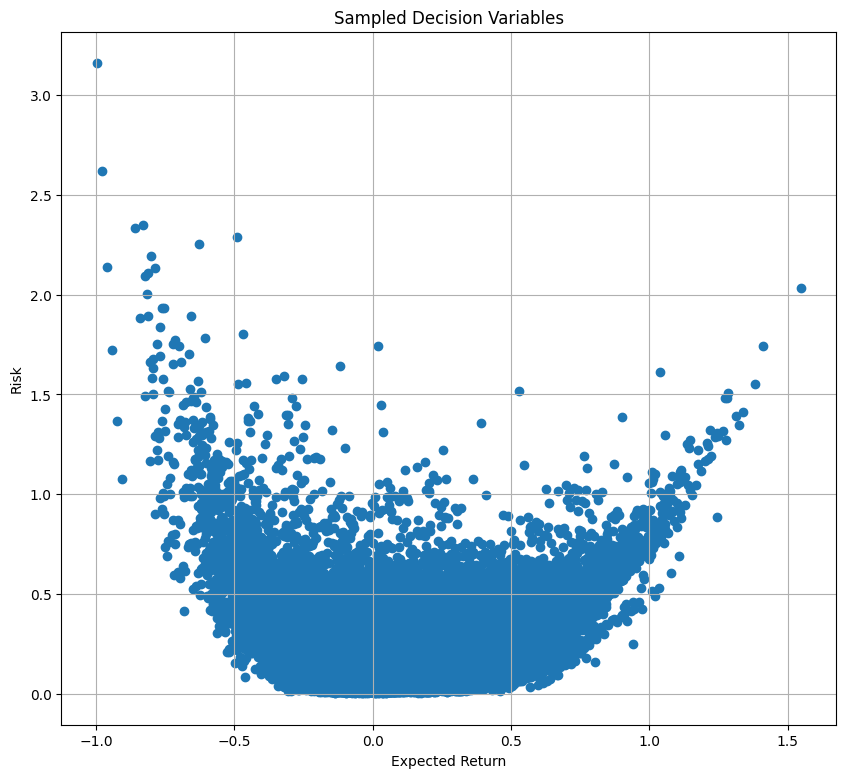

In [18]:
solver.plot_sampled_decision_variables(20, 0.2)

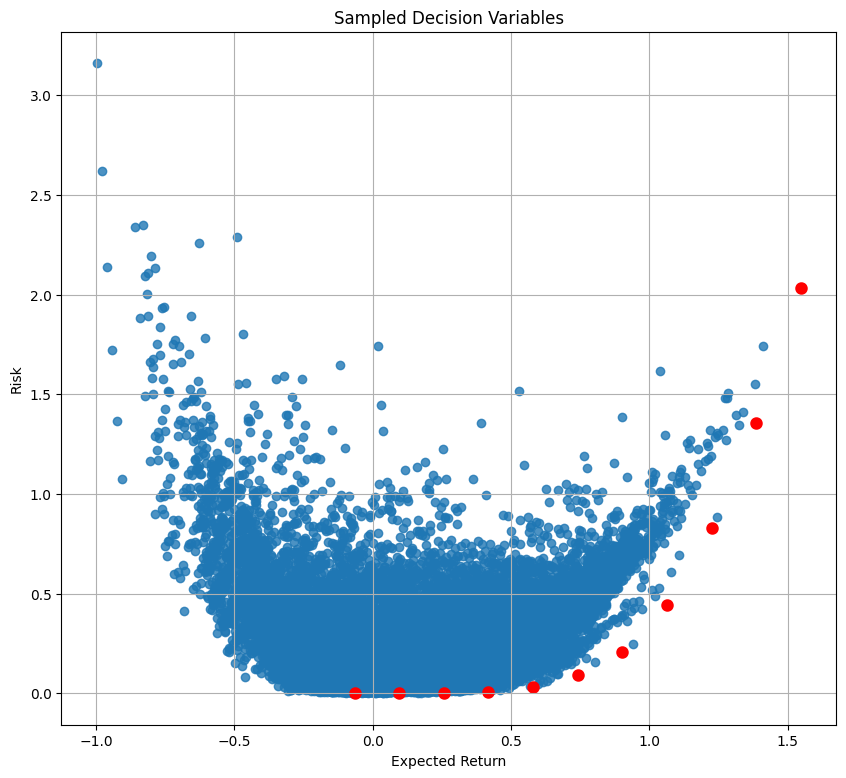

In [19]:
solver.plot_front(solutions, n=20, step=0.2)

## Comparison

### Single Threshold/Step Tests

In [20]:
thresholds = [20]
steps = [1/20]

ER = ExperimentRunner(solver=solver)
ER.run_ECM(thresholds)
ER.run_WSM(steps)

Running for threshold=-0.06547116796763697
     pcost       dcost       gap    pres   dres
 0:  1.6023e-03 -2.2019e+01  8e+01  1e+00  5e+00
 1:  6.7045e-02 -7.6597e+00  9e+00  3e-02  1e-01
 2:  2.6409e-02 -3.9753e-01  4e-01  1e-03  3e-03
 3:  2.3840e-03 -1.2391e-01  1e-01  1e-16  3e-16
 4:  1.1812e-03 -1.5254e-02  2e-02  2e-16  2e-16
 5:  5.1498e-04 -1.8706e-03  2e-03  2e-16  2e-16
 6:  2.4197e-04 -4.7226e-04  7e-04  1e-16  1e-16
 7:  1.9407e-04  1.0022e-04  9e-05  1e-16  1e-16
 8:  1.7828e-04  1.7255e-04  6e-06  2e-16  1e-16
 9:  1.7649e-04  1.7616e-04  3e-07  2e-16  2e-16
10:  1.7639e-04  1.7636e-04  3e-08  1e-16  2e-16
Optimal solution found.
Running for threshold=0.019486478788437275
     pcost       dcost       gap    pres   dres
 0:  1.9536e-03 -2.1663e+01  2e+01  7e-16  5e+00
 1:  1.6937e-03 -5.2592e-01  5e-01  2e-16  1e-01
 2:  9.0740e-04 -3.6234e-02  4e-02  2e-16  8e-03
 3:  4.0861e-04 -2.9628e-03  3e-03  2e-16  2e-16
 4:  2.9250e-04 -1.2093e-04  4e-04  2e-16  2e-16
 5:  2.536

In [21]:
top_ecm, top_wsm = ER.summarize()
top_wsm

,Solution Signature,Frequency,Method
0,"(0.9999999874036443, 2.3631031837347714e-10, 7...",1,WSM
1,"(0.9999999718710619, 5.922226255547871e-10, 1....",1,WSM
2,"(0.9999999093837567, 1.0126029676333856e-09, 3...",1,WSM
3,"(0.9839006156305068, 6.329091571192039e-11, 2....",1,WSM
4,"(0.8281992424607817, 9.612174326255307e-10, 2....",1,WSM
5,"(0.7347781678699946, 2.9739797167540153e-10, 6...",1,WSM
6,"(0.6724972158317536, 7.080067284664922e-09, 6....",1,WSM
7,"(0.6280110009585925, 9.244794405952633e-09, 5....",1,WSM
8,"(0.5946462630167608, 1.4374493922566733e-08, 4...",1,WSM
9,"(0.5686957129170604, 2.522210191158999e-08, 3....",1,WSM


In [22]:
top_ecm

,Solution Signature,Frequency,Method
0,"(9.563754032137061e-08, 3.345371472801473e-07,...",1,ECM
1,"(5.984392195704522e-06, 2.6164136257983256e-07...",1,ECM
2,"(4.929617073528924e-07, 1.3155443496649366e-07...",1,ECM
3,"(8.640153201898506e-09, 1.5055193500427843e-08...",1,ECM
4,"(1.6027437084861466e-07, 3.733923207715761e-08...",1,ECM
5,"(0.0011289414114276672, 6.927768189951898e-09,...",1,ECM
6,"(0.11043831163441327, 2.4139341799293523e-09, ...",1,ECM
7,"(0.24994401480700673, 5.735788434917063e-08, 6...",1,ECM
8,"(0.38951658981934456, 4.808690356402533e-09, 5...",1,ECM
9,"(0.45465261917743904, 2.419178612248217e-09, 2...",1,ECM


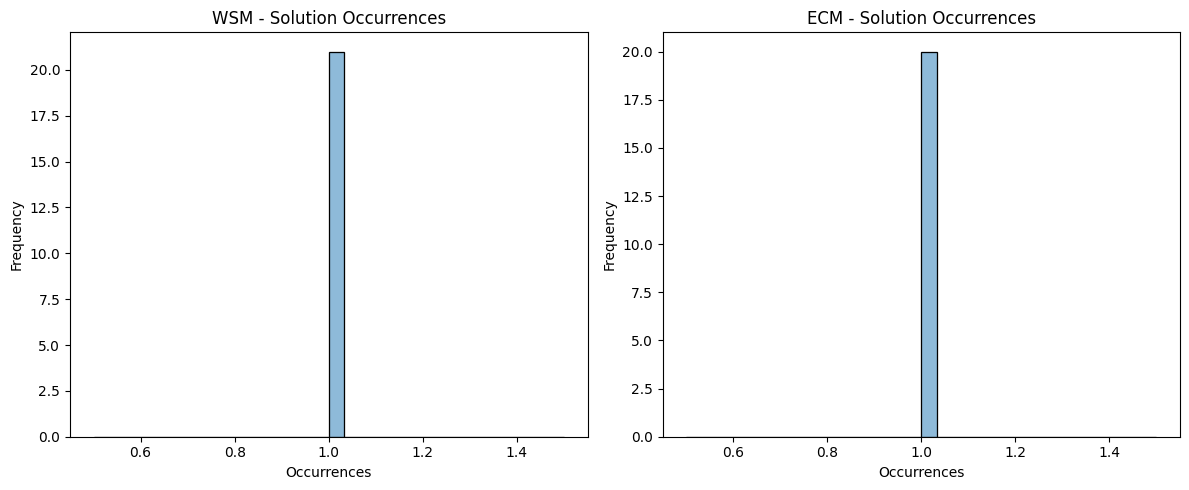

In [23]:
ER.plot_results()

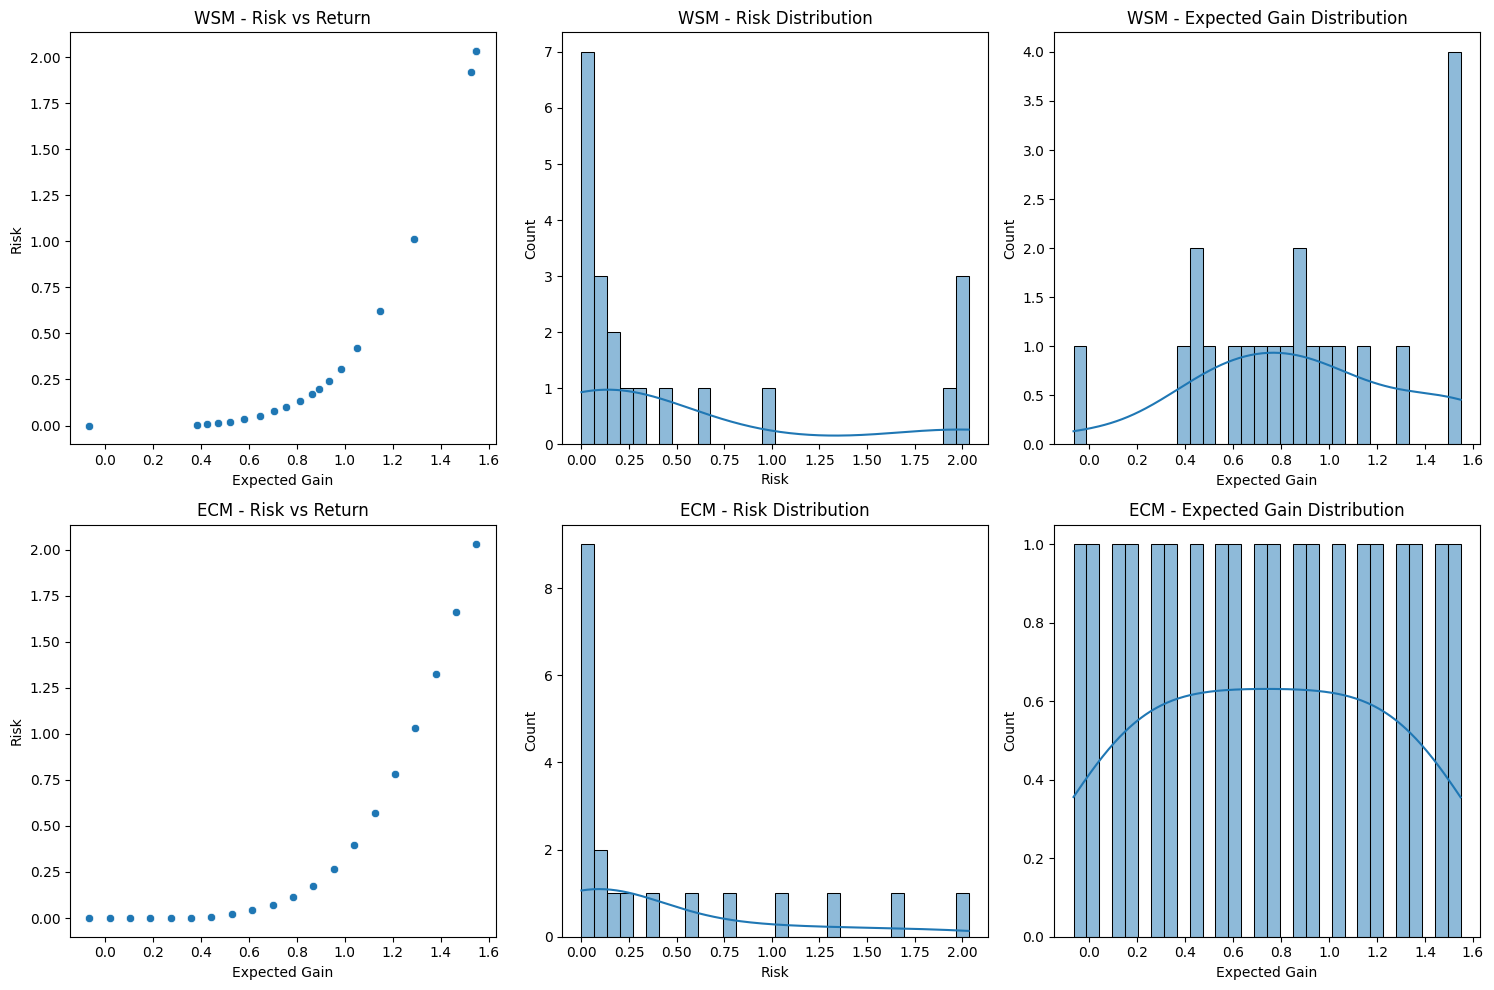

In [24]:
ER.plot_risk_return_distribution()

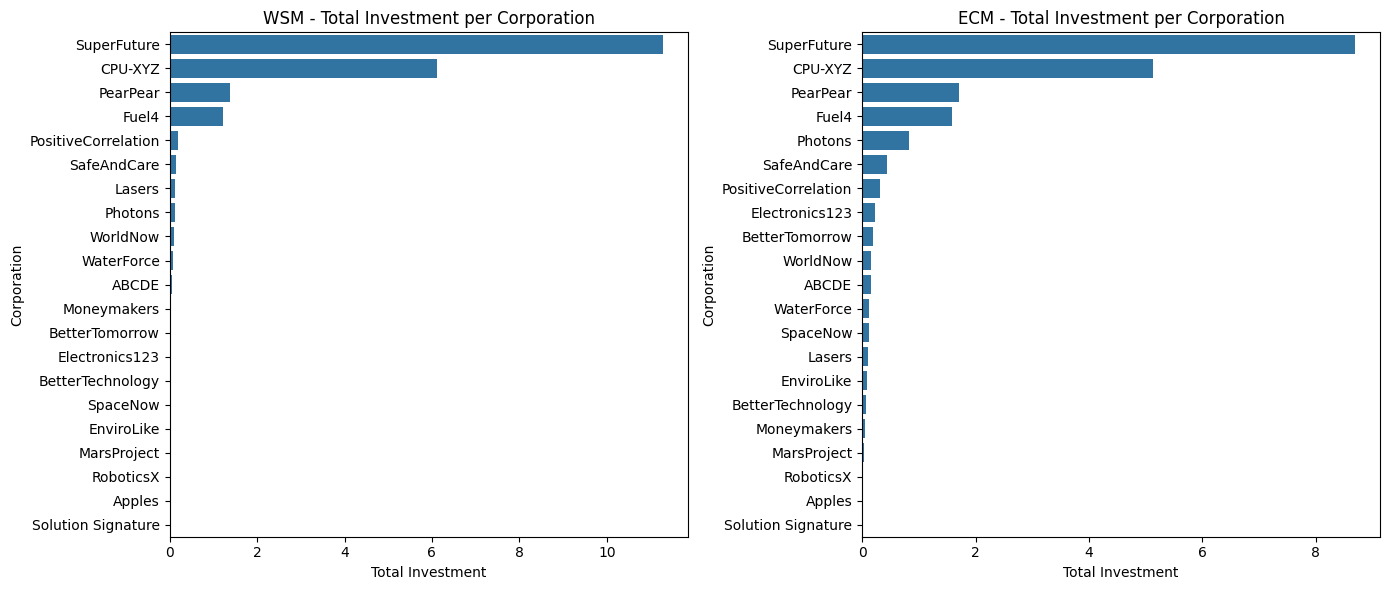

In [25]:
ER.plot_top_corporations()

### 2 to 32 Thresholds/Steps Experiments

In [26]:
thresholds = [2, 4, 8, 12, 16, 20, 32]
steps = [1/2, 1/4, 1/8, 1/16, 1/20, 1/32]

ER = ExperimentRunner(solver=solver)
ER.run_ECM(thresholds)
ER.run_WSM(steps)

Running for threshold=-0.06547116796763697
     pcost       dcost       gap    pres   dres
 0:  1.6023e-03 -2.2019e+01  8e+01  1e+00  5e+00
 1:  6.7045e-02 -7.6597e+00  9e+00  3e-02  1e-01
 2:  2.6409e-02 -3.9753e-01  4e-01  1e-03  3e-03
 3:  2.3840e-03 -1.2391e-01  1e-01  1e-16  3e-16
 4:  1.1812e-03 -1.5254e-02  2e-02  2e-16  2e-16
 5:  5.1498e-04 -1.8706e-03  2e-03  2e-16  2e-16
 6:  2.4197e-04 -4.7226e-04  7e-04  1e-16  1e-16
 7:  1.9407e-04  1.0022e-04  9e-05  1e-16  1e-16
 8:  1.7828e-04  1.7255e-04  6e-06  2e-16  1e-16
 9:  1.7649e-04  1.7616e-04  3e-07  2e-16  2e-16
10:  1.7639e-04  1.7636e-04  3e-08  1e-16  2e-16
Optimal solution found.
Running for threshold=1.5487241203977737
     pcost       dcost       gap    pres   dres
 0:  1.2015e-01 -2.1802e+01  1e+02  2e+00  5e+00
 1:  7.1526e-01 -1.1027e+01  2e+01  3e-01  6e-01
 2:  1.4049e+00 -2.3266e+00  7e+00  7e-02  2e-01
 3:  1.9012e+00  1.5836e+00  7e-01  7e-03  2e-02
 4:  2.0319e+00  2.0285e+00  8e-03  8e-05  2e-04
 5:  2.0334e

In [27]:
top_ecm, top_wsm = ER.summarize()
top_wsm

,Solution Signature,Frequency,Method
0,"(0.9999999874036443, 2.3631031837347714e-10, 7...",6,WSM
1,"(0.5479359178699503, 8.211287107625216e-10, 2....",6,WSM
2,"(1.6432982855287148e-07, 1.270240505356257e-07...",6,WSM
3,"(0.7347781678699946, 2.9739797167540153e-10, 6...",5,WSM
4,"(0.33562659188766275, 5.471284782878683e-09, 4...",5,WSM
5,"(0.9999995959395155, 1.4192110904479235e-09, 6...",3,WSM
6,"(0.6102164920080133, 1.1438203852442915e-08, 4...",3,WSM
7,"(0.47157807899094517, 3.668451902108686e-09, 2...",3,WSM
8,"(0.11389009072476021, 1.0467081163000417e-09, ...",3,WSM
9,"(0.9999999658453385, 6.843295873730394e-10, 1....",2,WSM


In [28]:
top_ecm

,Solution Signature,Frequency,Method
0,"(9.563754032137061e-08, 3.345371472801473e-07,...",7,ECM
1,"(0.9999998876179013, -4.580266880508286e-09, -...",7,ECM
2,"(0.15689157681957747, 7.267761302030504e-10, 6...",2,ECM
3,"(0.6458721716269329, 2.3700208769985138e-09, 1...",2,ECM
4,"(7.643853142285273e-09, 2.4674371681081067e-08...",1,ECM
5,"(0.041289879942660465, 3.342746558193731e-09, ...",1,ECM
6,"(0.40944995731052436, 2.434594809356971e-08, 3...",1,ECM
7,"(0.5446930698764436, 6.8576700199145486e-09, 1...",1,ECM
8,"(0.6964618503458091, 6.107911073611937e-10, 7....",1,ECM
9,"(0.8482308764903334, 3.7360480560478325e-11, 7...",1,ECM


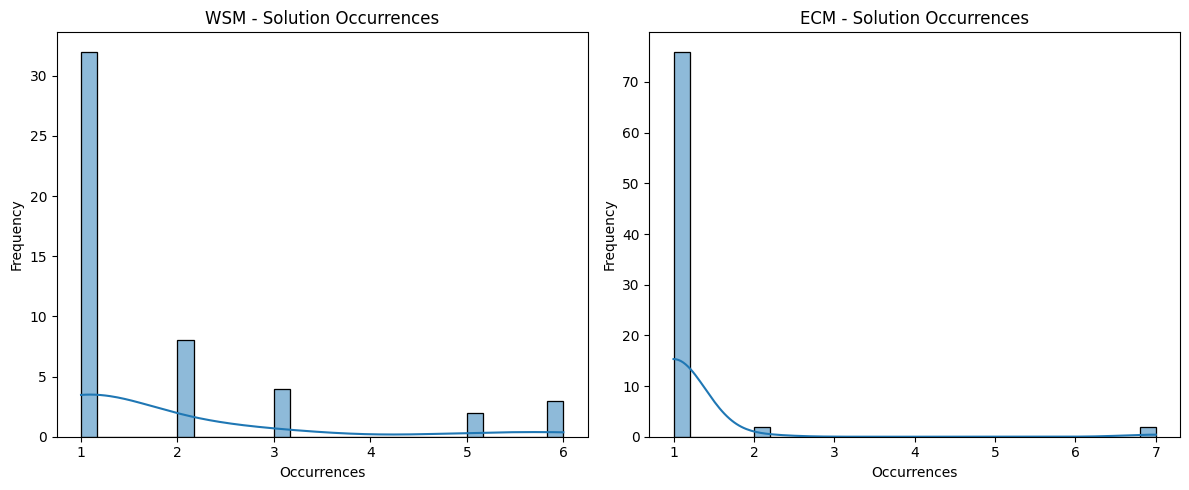

In [29]:
ER.plot_results()

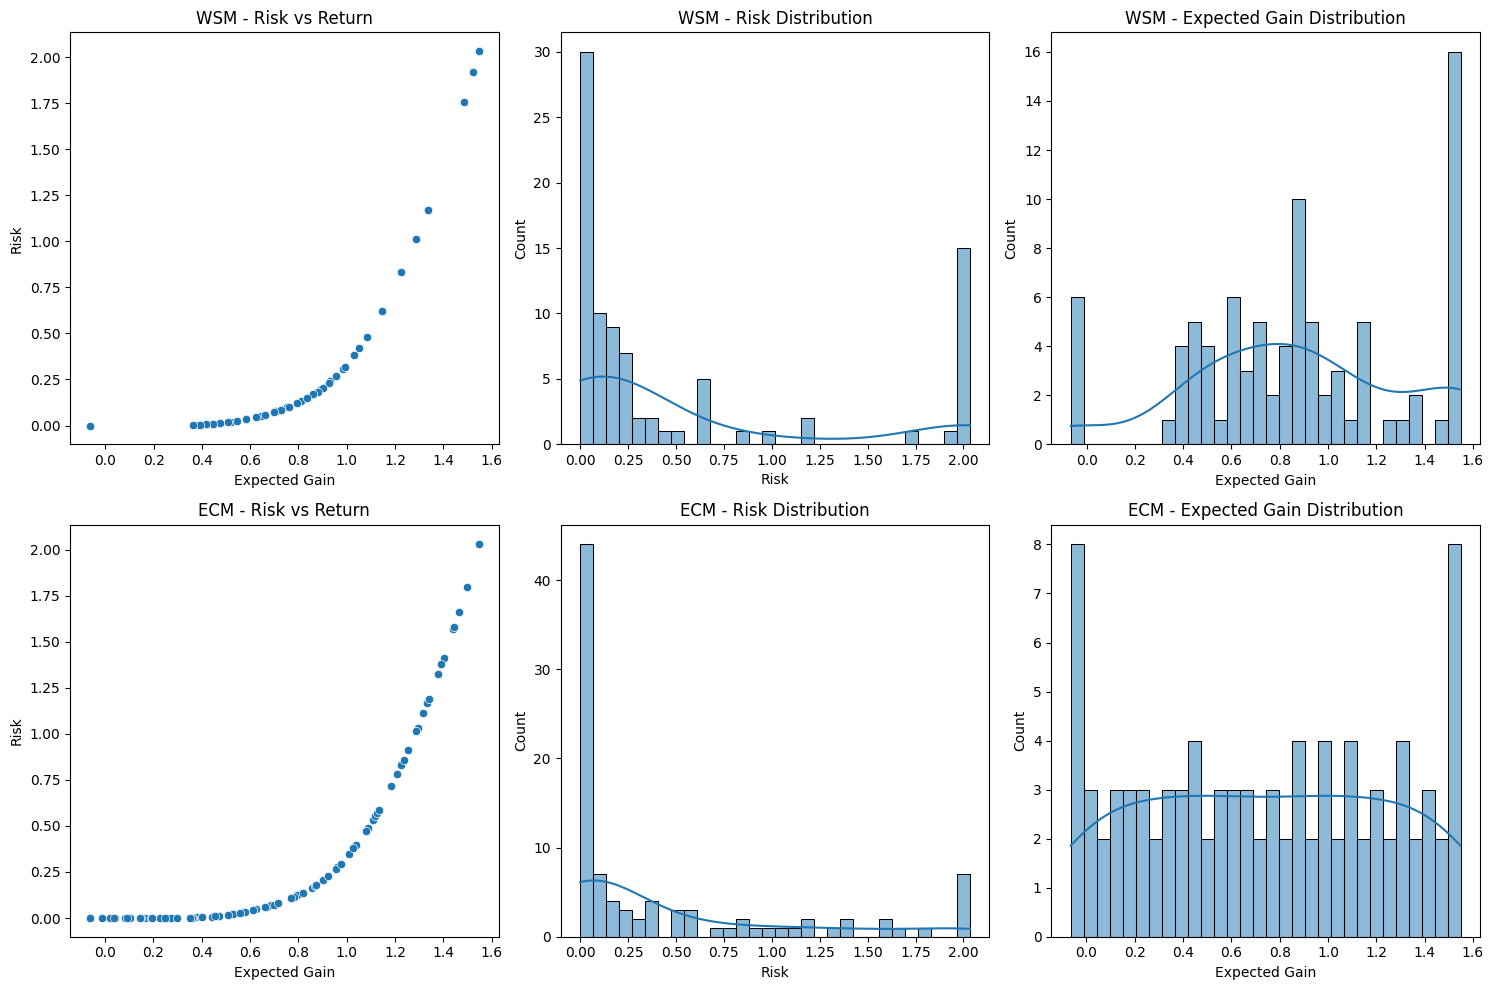

In [30]:
ER.plot_risk_return_distribution()

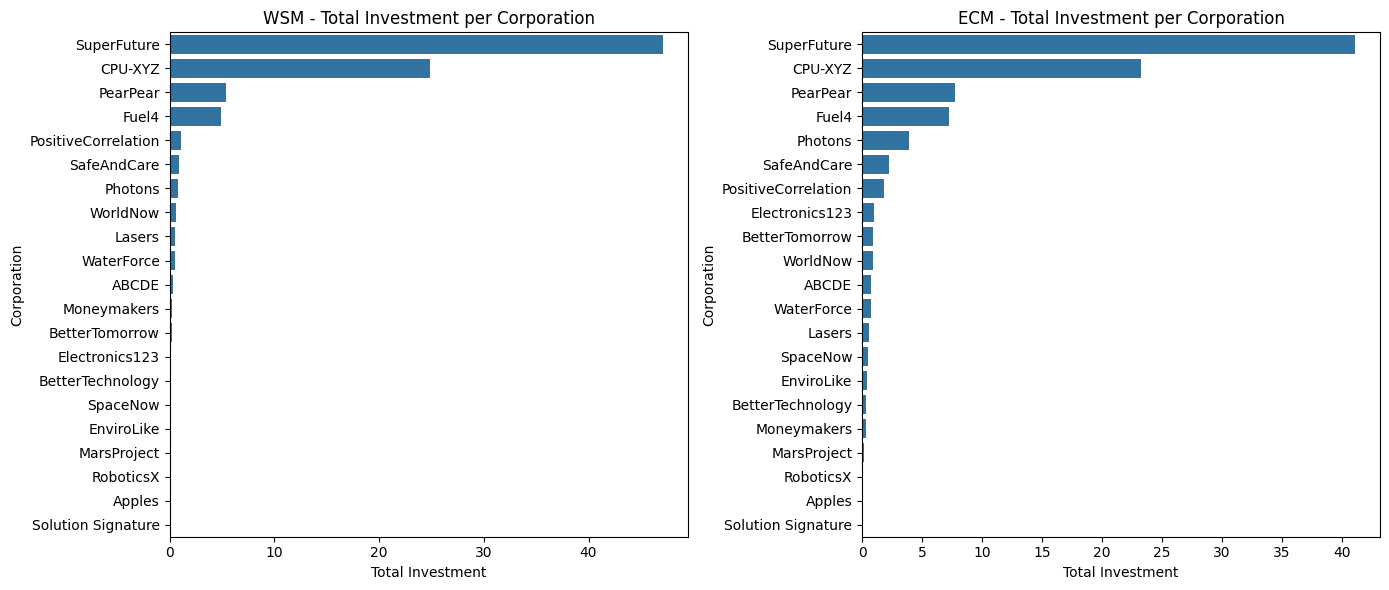

In [31]:
ER.plot_top_corporations()

### 2 to 256 Thresholds/Steps Experiments

In [32]:
thresholds = [2, 4, 8, 12, 16, 20, 32, 64, 128, 256]
steps = [1/2, 1/4, 1/8, 1/16, 1/20, 1/32, 1/64, 1/128, 1/256]

ER = ExperimentRunner(solver=solver)
ER.run_ECM(thresholds)
ER.run_WSM(steps)

Running for threshold=-0.06547116796763697
     pcost       dcost       gap    pres   dres
 0:  1.6023e-03 -2.2019e+01  8e+01  1e+00  5e+00
 1:  6.7045e-02 -7.6597e+00  9e+00  3e-02  1e-01
 2:  2.6409e-02 -3.9753e-01  4e-01  1e-03  3e-03
 3:  2.3840e-03 -1.2391e-01  1e-01  1e-16  3e-16
 4:  1.1812e-03 -1.5254e-02  2e-02  2e-16  2e-16
 5:  5.1498e-04 -1.8706e-03  2e-03  2e-16  2e-16
 6:  2.4197e-04 -4.7226e-04  7e-04  1e-16  1e-16
 7:  1.9407e-04  1.0022e-04  9e-05  1e-16  1e-16
 8:  1.7828e-04  1.7255e-04  6e-06  2e-16  1e-16
 9:  1.7649e-04  1.7616e-04  3e-07  2e-16  2e-16
10:  1.7639e-04  1.7636e-04  3e-08  1e-16  2e-16
Optimal solution found.
Running for threshold=1.5487241203977737
     pcost       dcost       gap    pres   dres
 0:  1.2015e-01 -2.1802e+01  1e+02  2e+00  5e+00
 1:  7.1526e-01 -1.1027e+01  2e+01  3e-01  6e-01
 2:  1.4049e+00 -2.3266e+00  7e+00  7e-02  2e-01
 3:  1.9012e+00  1.5836e+00  7e-01  7e-03  2e-02
 4:  2.0319e+00  2.0285e+00  8e-03  8e-05  2e-04
 5:  2.0334e

In [33]:
top_ecm, top_wsm = ER.summarize()
top_wsm

,Solution Signature,Frequency,Method
0,"(0.5479359178699503, 8.211287107625216e-10, 2....",9,WSM
1,"(1.6432982855287148e-07, 1.270240505356257e-07...",9,WSM
2,"(0.9999999874036443, 2.3631031837347714e-10, 7...",9,WSM
3,"(0.7347781678699946, 2.9739797167540153e-10, 6...",8,WSM
4,"(0.33562659188766275, 5.471284782878683e-09, 4...",8,WSM
5,"(0.6102164920080133, 1.1438203852442915e-08, 4...",6,WSM
6,"(0.9999995959395155, 1.4192110904479235e-09, 6...",6,WSM
7,"(0.47157807899094517, 3.668451902108686e-09, 2...",6,WSM
8,"(0.11389009072476021, 1.0467081163000417e-09, ...",6,WSM
9,"(0.4363771108565741, 1.395334491202704e-09, 1....",5,WSM


In [34]:
top_ecm

,Solution Signature,Frequency,Method
0,"(0.9999998876179013, -4.580266880508286e-09, -...",10,ECM
1,"(9.563754032137061e-08, 3.345371472801473e-07,...",10,ECM
2,"(0.15689157681957747, 7.267761302030504e-10, 6...",4,ECM
3,"(0.6458721716269329, 2.3700208769985138e-09, 1...",4,ECM
4,"(0.44924625659225936, 6.706423784586129e-09, 3...",2,ECM
5,"(0.5091765968544887, 8.223499623153672e-10, 2....",2,ECM
6,"(0.5750466333173491, 3.8792805875742584e-10, 7...",2,ECM
7,"(0.7166977209451625, 3.873859502730094e-10, 5....",2,ECM
8,"(0.7875232667418968, 6.990388506671504e-11, 1....",2,ECM
9,"(0.8583487991896155, 3.0818710327189986e-09, 6...",2,ECM


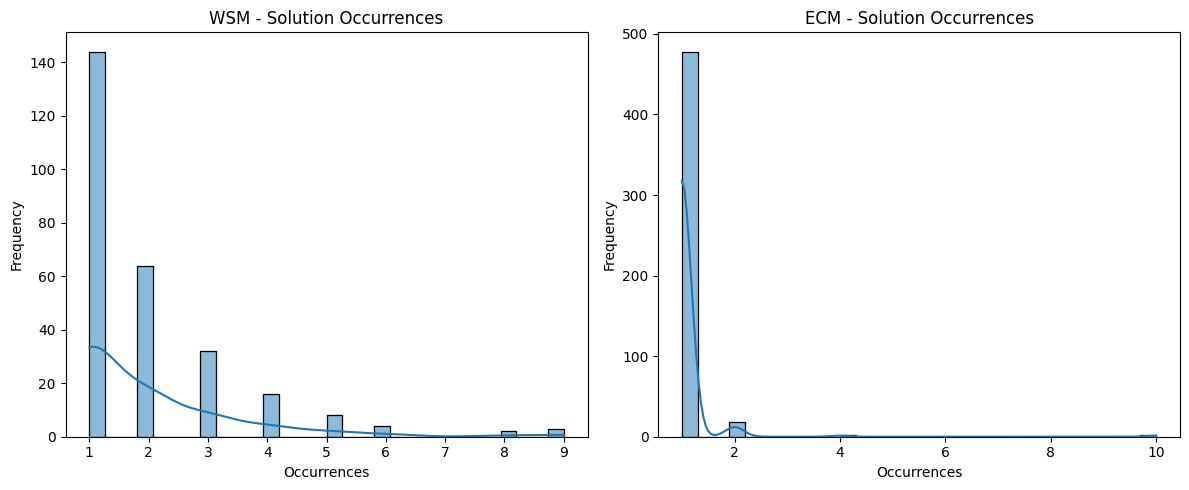

In [35]:
ER.plot_results()

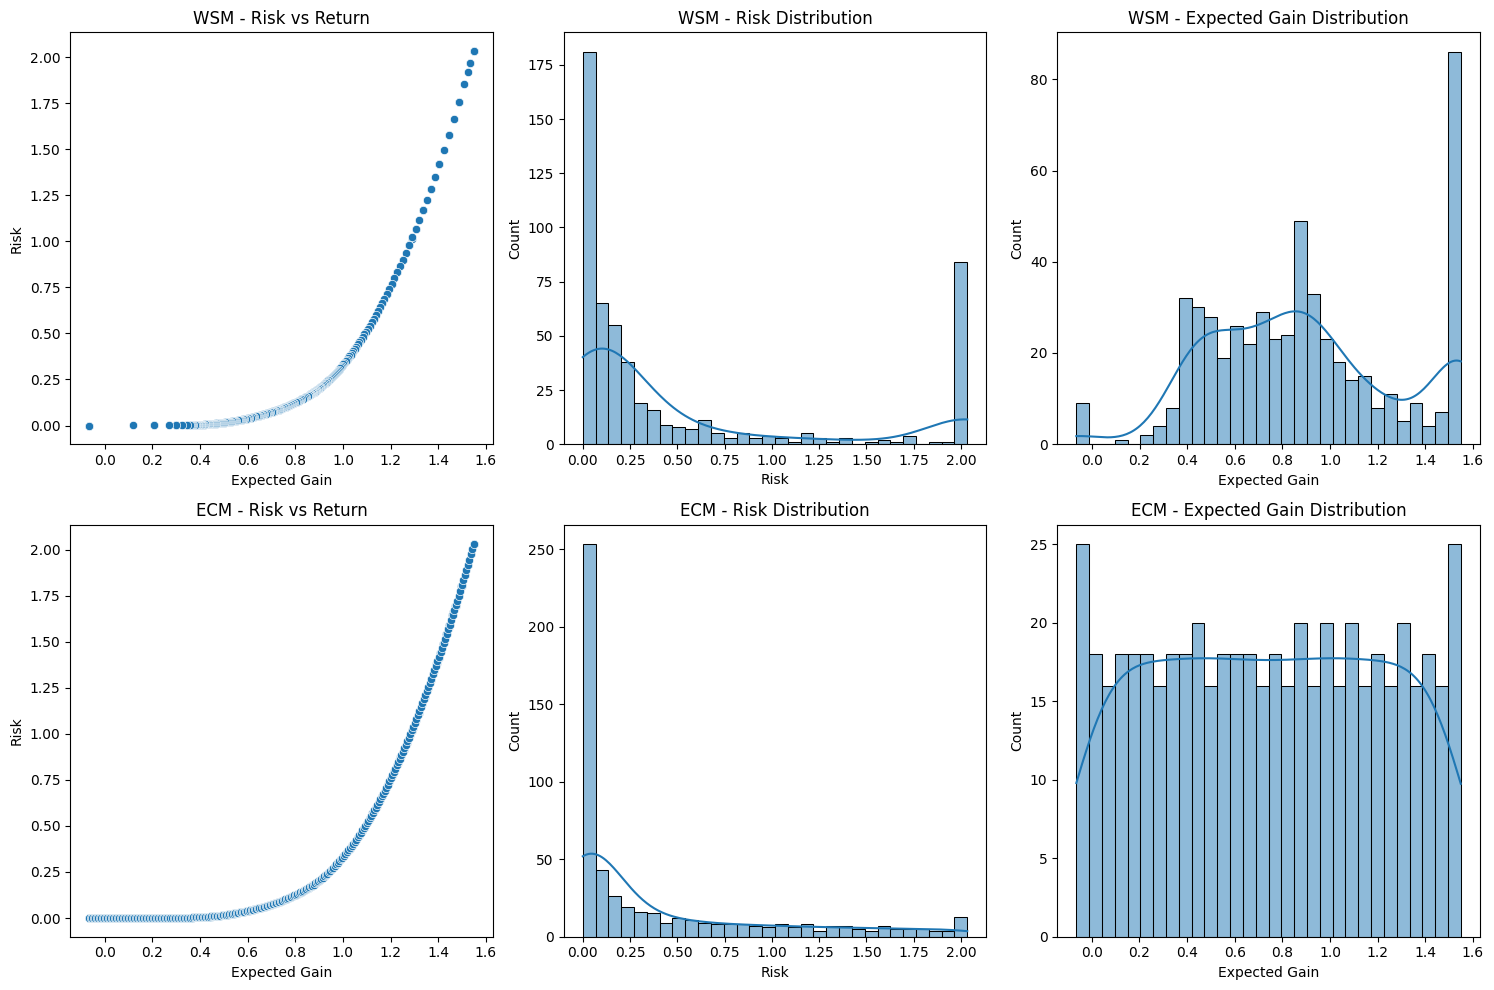

In [36]:
ER.plot_risk_return_distribution()

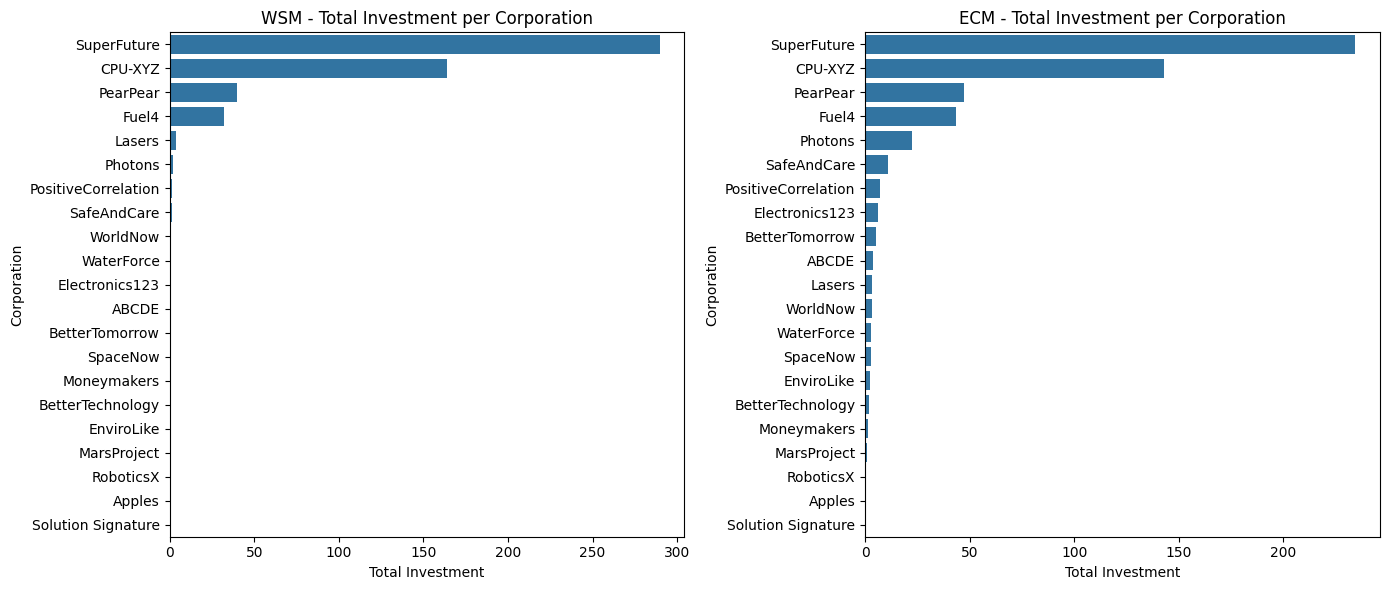

In [37]:
ER.plot_top_corporations()

In [47]:
ECM_results = ER.results_ECM
ECM_results_filtered = ECM_results[ECM_results["Expected Gain"] > 0]
ECM_results_sorted = ECM_results_filtered.sort_values(by="Risk", ascending=True)
ECM_results_sorted.drop(columns=["Solution Signature"], inplace=True)

ECM_results_sorted = ECM_results_sorted.head(40)
ECM_results_sorted

,Expected Gain,Risk,SuperFuture,Apples,WorldNow,Electronics123,Photons,SpaceNow,PearPear,PositiveCorrelation,...,Moneymakers,Fuel4,MarsProject,CPU-XYZ,RoboticsX,Lasers,WaterForce,SafeAndCare,BetterTomorrow,Sanity Check
297,0.004161,0.000223,5.486632e-06,4.330676e-07,5.417206e-02,0.041582,0.186136,0.021688,0.034791,0.112172,...,2.047094e-02,0.124061,0.009490,0.073980,6.453149e-06,0.000116,0.053212,0.133638,0.041321,1.0
298,0.010491,0.000230,5.011026e-06,2.728392e-07,5.082152e-02,0.042500,0.188351,0.021930,0.039710,0.106988,...,1.847970e-02,0.126532,0.009773,0.077625,4.454893e-06,0.000141,0.050112,0.132060,0.042195,1.0
164,0.010790,0.000231,4.976308e-06,2.642175e-07,5.066315e-02,0.042544,0.188456,0.021942,0.039942,0.106744,...,1.838563e-02,0.126649,0.009786,0.077797,4.359458e-06,0.000142,0.049966,0.131985,0.042237,1.0
97,0.011395,0.000231,4.903054e-06,2.466194e-07,5.034261e-02,0.042632,0.188668,0.021965,0.040412,0.106248,...,1.819526e-02,0.126885,0.009813,0.078146,4.166396e-06,0.000144,0.049670,0.131834,0.042320,1.0
299,0.016821,0.000239,5.708565e-06,2.270707e-07,4.748126e-02,0.043416,0.190576,0.022171,0.044622,0.101793,...,1.649103e-02,0.129008,0.010055,0.081268,4.192756e-06,0.000192,0.047010,0.130468,0.043061,1.0
43,0.019487,0.000242,5.984392e-06,2.616414e-07,4.607494e-02,0.043801,0.191513,0.022272,0.046691,0.099605,...,1.565477e-02,0.130051,0.010174,0.082802,4.260729e-06,0.000214,0.045703,0.129796,0.043425,1.0
300,0.023152,0.000247,6.067838e-06,2.958927e-07,4.413943e-02,0.044332,0.192799,0.022413,0.049536,0.096599,...,1.450605e-02,0.131483,0.010338,0.084912,4.194142e-06,0.000242,0.043906,0.128875,0.043927,1.0
165,0.023501,0.000248,6.059451e-06,2.980472e-07,4.395504e-02,0.044382,0.192922,0.022426,0.049807,0.096313,...,1.439677e-02,0.131619,0.010353,0.085113,4.179484e-06,0.000245,0.043735,0.128787,0.043975,1.0
301,0.029482,0.000257,5.546869e-06,3.074593e-07,4.079077e-02,0.045247,0.195018,0.022658,0.054453,0.091412,...,1.252677e-02,0.133953,0.010619,0.088557,3.768042e-06,0.000283,0.040799,0.127285,0.044796,1.0
302,0.035812,0.000267,4.510318e-06,2.696161e-07,3.743318e-02,0.046163,0.197232,0.022908,0.059372,0.086232,...,1.055914e-02,0.136416,0.010900,0.092204,3.151304e-06,0.000314,0.037685,0.125697,0.045668,1.0


In [53]:
def save_solution(df, index, value, filename="solution.txt"):
    if index not in df.index:
        print(f"Error: Index {index} not found in DataFrame.")
        return
    
    row = df.loc[index]
    expected_total_return = (1.0 + row["Expected Gain"]) * value
    expected_total_risk = row["Risk"]
    weights = [row[company] for company in ORDER]
    solution_line = f"{expected_total_return:.2f} {expected_total_risk:.2f} " + " ".join(f"{w:.2f}" for w in weights)
    with open(filename, "w") as file:
        file.write(solution_line)
    print(f"Solution saved successfully in {filename} with a produced weight sum: {sum(weights)}")

save_solution(ECM_results_sorted, 297, 100, filename="stage_1_safest.txt")
save_solution(ECM_results_sorted, 305, 100, filename="stage_1_mid.txt")
save_solution(ECM_results_sorted, 316, 100, filename="stage_1_risky.txt")

Solution saved successfully in stage_1_safest.txt with a produced weight sum: 0.9999999999999999
Solution saved successfully in stage_1_mid.txt with a produced weight sum: 0.9999999999999999
Solution saved successfully in stage_1_risky.txt with a produced weight sum: 1.0
